<a href="https://www.kaggle.com/code/mrrogueknight/nutrition-health-survey-age-prediction?scriptVersionId=335042103" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nutrition-health-survey/Train_Data.csv
/kaggle/input/nutrition-health-survey/Test_Data.csv


In [2]:
# WARNING: This command will permanently delete all files and folders
# inside /kaggle/working/.

# First, list the files to see what will be deleted
print("--- Before Deletion ---")
!ls -l /kaggle/working/

# Now, delete everything inside the directory
!rm -rf /kaggle/working/*

# Verify that the directory is empty
print("\n--- After Deletion ---")
!ls -l /kaggle/working/

--- Before Deletion ---
total 0

--- After Deletion ---
total 0


In [3]:
import warnings
warnings.filterwarnings("ignore")

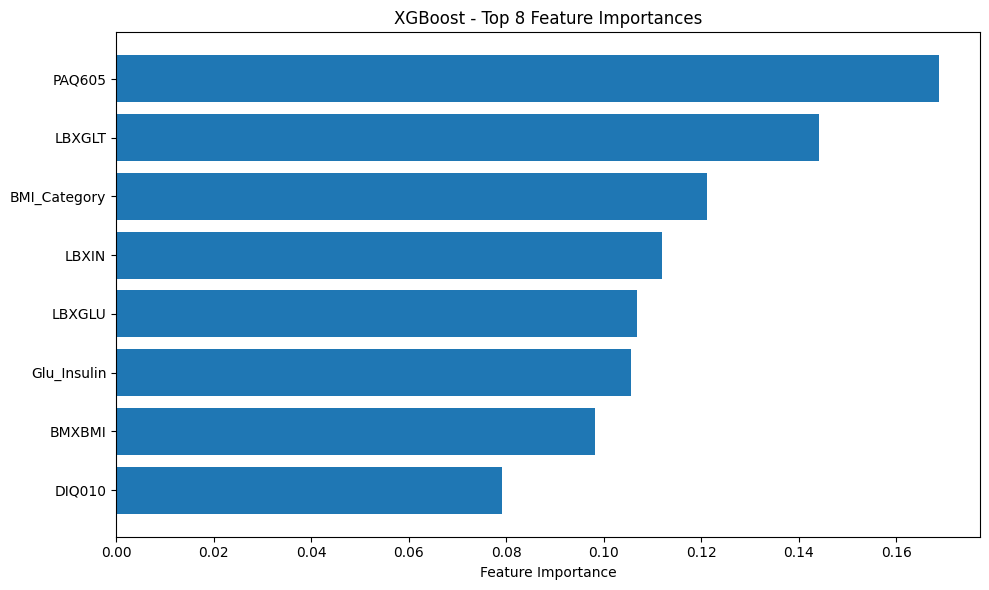

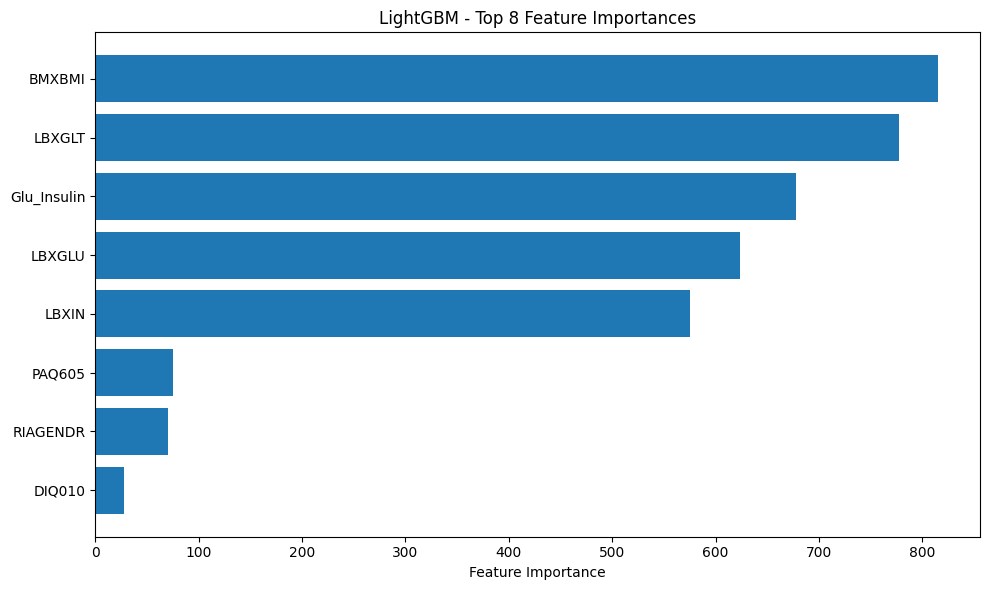

In [26]:
"""
Nutrition Health Survey - Age Prediction
=========================================
Binary classification model to predict Senior (65+) vs Adult using NHANES health indicators.

Authors: Prashant Ranjan & Uday Tripathi
Competition: Summer Analytics 2025 - IIT Guwahati
Rank: Top 32 (Private Leaderboard)
"""

import os
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_recall_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from joblib import dump, load

# Suppress warnings
warnings.filterwarnings("ignore")

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    "xgb_params": {
        "n_estimators": 400,
        "learning_rate": 0.07,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42
    },
    "lgb_params": {
        "n_estimators": 400,
        "learning_rate": 0.07,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "class_weight": "balanced",
        "random_state": 42,
        "verbose": -1
    },
    "folds": 5,
    "random_state": 42,
    "threshold": 0.5  # Default ensemble threshold
}

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger(__name__)


# ============================================================================
# DATA PREPROCESSING
# ============================================================================

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature engineering for health survey data.
    
    Args:
        df: Input DataFrame with raw features
        
    Returns:
        DataFrame with engineered features
    """
    df = df.copy()
    
    # BMI categorization (Underweight, Normal, Overweight, Obese)
    df["BMI_Category"] = pd.cut(
        df["BMXBMI"], 
        bins=[0, 18.5, 25, 30, 100], 
        labels=[0, 1, 2, 3]
    ).astype(float)
    
    # High glucose indicator (diabetes risk)
    df["High_Glucose"] = (df["LBXGLU"] > 125).astype(float)
    
    # Glucose-Insulin interaction feature
    df["Glu_Insulin"] = df["LBXGLU"] * df["LBXIN"]
    
    return df


def build_pipeline() -> Pipeline:
    """
    Build sklearn pipeline for imputation and scaling.
    
    Returns:
        Pipeline with imputer and scaler
    """
    return Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])


def load_and_prepare_data(train_path: str, test_path: str):
    """
    Load and prepare training and test data.
    
    Args:
        train_path: Path to training CSV
        test_path: Path to test CSV
        
    Returns:
        Tuple of (X_train, X_test, y_train, test_ids, feature_names)
    """
    logger.info(f"Loading data from {train_path} and {test_path}")
    
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    # Drop rows with missing target
    train_df = train_df.dropna(subset=["age_group"])
    
    # Encode target
    y_train = train_df["age_group"].map({'Adult': 0, 'Senior': 1}).astype(int)
    test_ids = test_df["SEQN"]
    
    # Drop SEQN and target for features
    X_train = train_df.drop(columns=["SEQN", "age_group"])
    X_test = test_df.drop(columns=["SEQN"])
    
    # Feature engineering
    X_train = preprocess(X_train)
    X_test = preprocess(X_test)
    
    feature_names = X_train.columns.tolist()
    
    logger.info(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
    logger.info(f"Features: {feature_names}")
    
    return X_train, X_test, y_train, test_ids, feature_names


# ============================================================================
# MODEL TRAINING & EVALUATION
# ============================================================================

def cross_validate_with_threshold_tuning(model, X, y, folds: int = 5):
    """
    Cross-validate model and tune decision threshold using F1 score.
    
    Args:
        model: Sklearn-compatible classifier
        X: Feature matrix
        y: Target labels
        folds: Number of CV folds
        
    Returns:
        Best threshold averaged across folds
    """
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=CONFIG["random_state"])
    f1_scores = []
    thresholds = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Train model
        model.fit(X_train, y_train)
        
        # Get probabilities
        probs = model.predict_proba(X_val)[:, 1]
        
        # Find optimal threshold using precision-recall curve
        precision, recall, thresholds_all = precision_recall_curve(y_val, probs)
        f1_scores_curve = 2 * precision * recall / (precision + recall + 1e-6)
        best_thresh = thresholds_all[np.argmax(f1_scores_curve)]
        
        # Evaluate
        preds = (probs >= best_thresh).astype(int)
        score = f1_score(y_val, preds)
        
        f1_scores.append(score)
        thresholds.append(best_thresh)
        
        logger.info(f"  Fold {fold}: F1 = {score:.4f}, Threshold = {best_thresh:.3f}")
    
    avg_f1 = np.mean(f1_scores)
    avg_threshold = np.mean(thresholds)
    
    logger.info(f"  Average F1: {avg_f1:.4f}, Avg Threshold: {avg_threshold:.3f}")
    
    return avg_threshold


def plot_feature_importance(model, model_name: str, features: list, top_n: int = 10):
    """
    Plot feature importance for tree-based models.
    
    Args:
        model: Trained tree-based model
        model_name: Name for plot title
        features: List of feature names
        top_n: Number of top features to display
    """
    if not hasattr(model, 'feature_importances_'):
        logger.warning(f"{model_name} does not have feature_importances_ attribute")
        return
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.title(f'{model_name} - Top {top_n} Feature Importances')
    plt.tight_layout()
    plt.show()


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_pipeline(train_path: str, test_path: str, output_dir: str = "."):
    """
    Run the complete training and prediction pipeline.
    
    Args:
        train_path: Path to training data CSV
        test_path: Path to test data CSV
        output_dir: Directory to save outputs
    """
    logger.info("=" * 60)
    logger.info("Starting Nutrition Health Survey - Age Prediction Pipeline")
    logger.info("=" * 60)
    
    # 1. Load and prepare data
    X_train, X_test, y_train, test_ids, features = load_and_prepare_data(
        train_path, test_path
    )
    
    # 2. Preprocessing pipeline (imputation + scaling)
    logger.info("Applying preprocessing pipeline...")
    pipeline = build_pipeline()
    X_train_scaled = pipeline.fit_transform(X_train)
    X_test_scaled = pipeline.transform(X_test)
    
    # 3. Calculate class imbalance ratio for XGBoost
    n_adult = (y_train == 0).sum()
    n_senior = (y_train == 1).sum()
    scale_pos_weight = n_adult / n_senior
    logger.info(f"Class distribution - Adult: {n_adult}, Senior: {n_senior}")
    logger.info(f"Scale pos weight: {scale_pos_weight:.2f}")
    
    # 4. Initialize models
    xgb_model = XGBClassifier(
        **CONFIG["xgb_params"],
        scale_pos_weight=scale_pos_weight
    )
    lgb_model = LGBMClassifier(**CONFIG["lgb_params"])
    
    # 5. Cross-validate XGBoost
    logger.info("\n[1/2] XGBoost Cross-Validation")
    best_thresh_xgb = cross_validate_with_threshold_tuning(
        xgb_model, X_train_scaled, y_train, folds=CONFIG["folds"]
    )
    
    # 6. Train XGBoost on full data
    logger.info("Training XGBoost on full dataset...")
    xgb_model.fit(X_train_scaled, y_train)
    probs_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    # 7. Plot XGBoost feature importance
    plot_feature_importance(xgb_model, "XGBoost", features, top_n=8)
    
    # 8. Cross-validate LightGBM
    logger.info("\n[2/2] LightGBM Cross-Validation")
    best_thresh_lgb = cross_validate_with_threshold_tuning(
        lgb_model, X_train_scaled, y_train, folds=CONFIG["folds"]
    )
    
    # 9. Train LightGBM on full data
    logger.info("Training LightGBM on full dataset...")
    lgb_model.fit(X_train_scaled, y_train)
    probs_lgb = lgb_model.predict_proba(X_test_scaled)[:, 1]
    
    # 10. Plot LightGBM feature importance
    plot_feature_importance(lgb_model, "LightGBM", features, top_n=8)
    
    # 11. Ensemble predictions
    logger.info("\nEnsembling predictions...")
    final_probs = (probs_xgb + probs_lgb) / 2
    
    # Use optimal threshold (average of both models' thresholds)
    ensemble_threshold = (best_thresh_xgb + best_thresh_lgb) / 2
    logger.info(f"Ensemble threshold: {ensemble_threshold:.3f}")
    
    final_preds = (final_probs >= ensemble_threshold).astype(int)
    
    # 12. Create submission
    submission = pd.DataFrame({
        "SEQN": test_ids,
        "age_group": final_preds
    })
    
    # 13. Save outputs
    os.makedirs(output_dir, exist_ok=True)
    
    submission_path = os.path.join(output_dir, "final_submission.csv")
    submission.to_csv(submission_path, index=False)
    logger.info(f"Submission saved to: {submission_path}")
    
    # Save models
    xgb_path = os.path.join(output_dir, "xgb_model.joblib")
    lgb_path = os.path.join(output_dir, "lgb_model.joblib")
    pipeline_path = os.path.join(output_dir, "preprocessing_pipeline.joblib")
    
    dump(xgb_model, xgb_path)
    dump(lgb_model, lgb_path)
    dump(pipeline, pipeline_path)
    logger.info(f"Models saved to: {output_dir}")
    
    # 14. Summary
    logger.info("\n" + "=" * 60)
    logger.info(" Pipeline completed successfully!")
    logger.info(f"   Test samples predicted: {len(submission)}")
    logger.info(f"   Predictions distribution:")
    logger.info(f"   - Adult (0): {(final_preds == 0).sum()}")
    logger.info(f"   - Senior (1): {(final_preds == 1).sum()}")
    logger.info("=" * 60)
    
    return submission


# ============================================================================
# DATA EXPLORATION (Optional)
# ============================================================================

def exploratory_analysis(data_path: str):
    """
    Quick EDA for understanding the data.
    
    Args:
        data_path: Path to training CSV
    """
    df = pd.read_csv(data_path)
    
    print("\n" + "=" * 60)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 60)
    
    print(f"\n📊 Dataset Shape: {df.shape}")
    print(f"\n📋 Columns: {df.columns.tolist()}")
    print(f"\n🔍 Data Types:\n{df.dtypes}")
    print(f"\n📈 Missing Values:\n{df.isnull().sum()}")
    print(f"\n📊 Statistical Summary:\n{df.describe()}")
    
    # Target distribution
    if "age_group" in df.columns:
        print(f"\n🎯 Target Distribution:\n{df['age_group'].value_counts()}")
    
    # Correlation heatmap
    plt.figure(figsize=(10, 8))
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # For Kaggle environment
    train_path = "/kaggle/input/nutrition-health-survey/Train_Data.csv"
    test_path = "/kaggle/input/nutrition-health-survey/Test_Data.csv"
    output_dir = "/kaggle/working"
    
    # Uncomment for local execution
    # train_path = "data/Train_Data.csv"
    # test_path = "data/Test_Data.csv"
    # output_dir = "."
    
    # Run pipeline
    submission = run_pipeline(train_path, test_path, output_dir)
    
    # Optional: Run EDA
    # exploratory_analysis(train_path)

In [28]:
"""
Nutrition Health Survey - Age Prediction
=========================================
Production-grade binary classification system for predicting Senior (65+) vs Adult.
Competition: Summer Analytics 2025 - IIT Guwahati | Rank: Top 32

Authors: Prashant Ranjan & Uday Tripathi
Version: 2.0.0
"""

import os
import sys
import json
import logging
import warnings
import datetime
import pickle
from typing import Dict, Tuple, Optional, List, Any, Union
from dataclasses import dataclass, field, asdict
from pathlib import Path
from abc import ABC, abstractmethod
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, PowerTransformer,
    QuantileTransformer, LabelEncoder
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, GridSearchCV,
    RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    f1_score, precision_recall_curve, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, 
    precision_score, recall_score, accuracy_score
)
from sklearn.feature_selection import (
    SelectFromModel, RFE, mutual_info_classif,
    SelectKBest, VarianceThreshold
)
from sklearn.ensemble import (
    VotingClassifier, StackingClassifier, RandomForestClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from joblib import dump, load
import optuna

warnings.filterwarnings("ignore")

# ============================================================================
# LOGGING CONFIGURATION
# ============================================================================

def setup_logging(log_level: str = "INFO", log_file: Optional[str] = None) -> logging.Logger:
    """
    Configure logging for production environment.
    
    Args:
        log_level: Logging level (DEBUG, INFO, WARNING, ERROR)
        log_file: Optional path to log file
    
    Returns:
        Configured logger instance
    """
    logger = logging.getLogger("NutritionHealthSurvey")
    logger.setLevel(getattr(logging, log_level.upper()))
    
    # Remove existing handlers
    logger.handlers.clear()
    
    # Console handler
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_formatter = logging.Formatter(
        '%(asctime)s - %(name)s - %(levelname)s - %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    console_handler.setFormatter(console_formatter)
    logger.addHandler(console_handler)
    
    # File handler (if specified)
    if log_file:
        os.makedirs(os.path.dirname(log_file), exist_ok=True)
        file_handler = logging.FileHandler(log_file)
        file_handler.setLevel(logging.DEBUG)
        file_formatter = logging.Formatter(
            '%(asctime)s - %(name)s - %(levelname)s - %(filename)s:%(lineno)d - %(message)s'
        )
        file_handler.setFormatter(file_formatter)
        logger.addHandler(file_handler)
    
    return logger

logger = setup_logging(log_level="INFO", log_file="logs/training.log")


# ============================================================================
# CONFIGURATION MANAGEMENT
# ============================================================================

@dataclass
class FeatureEngineeringConfig:
    """Configuration for feature engineering pipeline."""
    
    create_bmi_categories: bool = True
    create_glucose_categories: bool = True
    create_insulin_categories: bool = True
    create_polynomial_features: bool = True
    create_interaction_features: bool = True
    create_clinical_scores: bool = True
    create_outlier_indicators: bool = True
    create_missing_indicators: bool = True
    use_log_transformations: bool = True
    use_sqrt_transformations: bool = True
    
    bmi_thresholds: List[float] = field(default_factory=lambda: [18.5, 25.0, 30.0])
    glucose_thresholds: List[float] = field(default_factory=lambda: [100.0, 126.0])
    insulin_threshold: float = 20.0


@dataclass
class ModelConfig:
    """Configuration for model training and evaluation."""
    
    # Model selection
    use_xgboost: bool = True
    use_lightgbm: bool = True
    use_catboost: bool = True
    use_stacking: bool = True
    use_voting: bool = False
    
    # Hyperparameters
    xgb_params: Dict = field(default_factory=lambda: {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "colsample_bylevel": 0.7,
        "min_child_weight": 3,
        "gamma": 0.1,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    })
    
    lgb_params: Dict = field(default_factory=lambda: {
        "n_estimators": 500,
        "learning_rate": 0.05,
        "max_depth": 6,
        "num_leaves": 31,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_samples": 20,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    })
    
    catboost_params: Dict = field(default_factory=lambda: {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 5,
        "subsample": 0.8,
        "l2_leaf_reg": 3,
        "border_count": 64,
        "loss_function": "Logloss",
        "verbose": False,
        "random_seed": 42
    })
    
    stacking_meta_params: Dict = field(default_factory=lambda: {
        "C": 1.0,
        "class_weight": "balanced",
        "max_iter": 1000,
        "random_state": 42
    })
    
    # Cross-validation
    n_folds: int = 5
    random_state: int = 42
    threshold: float = 0.5
    
    # Optimization
    optimize_hyperparams: bool = False
    n_trials: int = 50
    optimization_timeout: int = 3600
    
    # Feature selection
    use_feature_selection: bool = True
    feature_selection_method: str = "mutual_info"  # mutual_info, rfe, variance
    max_features: int = 20
    
    # Imputation
    use_knn_imputation: bool = False
    knn_neighbors: int = 5
    imputation_strategy: str = "median"  # mean, median, most_frequent
    
    # Scaling
    use_power_transform: bool = True
    scaling_method: str = "robust"  # robust, standard, quantile
    
    # Early stopping
    early_stopping_rounds: int = 50
    validation_split: float = 0.2


@dataclass
class DataConfig:
    """Configuration for data loading and validation."""
    
    train_path: str = "/kaggle/input/nutrition-health-survey/Train_Data.csv"
    test_path: str = "/kaggle/input/nutrition-health-survey/Test_Data.csv"
    output_dir: str = "/kaggle/working"
    
    target_column: str = "age_group"
    id_column: str = "SEQN"
    
    numeric_columns: List[str] = field(default_factory=lambda: [
        "RIAGENDR", "PAQ605", "BMXBMI", "LBXGLU", 
        "DIQ010", "LBXGLT", "LBXIN"
    ])
    
    categorical_columns: List[str] = field(default_factory=list)
    
    test_size: float = 0.2
    validation_size: float = 0.1
    
    random_state: int = 42


@dataclass
class ModelArtifacts:
    """Container for model artifacts and metadata."""
    
    models: Dict[str, Any] = field(default_factory=dict)
    preprocessing_pipeline: Optional[Pipeline] = None
    feature_engineer: Optional[Any] = None
    feature_names: List[str] = field(default_factory=list)
    selected_features: Optional[np.ndarray] = None
    thresholds: Dict[str, float] = field(default_factory=dict)
    cv_scores: Dict[str, List[float]] = field(default_factory=dict)
    best_model_name: str = ""
    best_f1_score: float = 0.0
    
    training_timestamp: str = ""
    training_duration: float = 0.0
    config_hash: str = ""
    
    # Performance metrics
    test_metrics: Dict[str, float] = field(default_factory=dict)
    
    def to_dict(self) -> Dict:
        return {
            "best_model": self.best_model_name,
            "best_f1": self.best_f1_score,
            "thresholds": self.thresholds,
            "cv_scores": self.cv_scores,
            "feature_count": len(self.feature_names) if self.feature_names else 0,
            "training_timestamp": self.training_timestamp,
            "training_duration": self.training_duration
        }


# ============================================================================
# DATA VALIDATION
# ============================================================================

class DataValidator:
    """
    Data validation and quality checks for production.
    """
    
    @staticmethod
    def validate_schema(df: pd.DataFrame, expected_columns: List[str]) -> bool:
        """Validate that dataframe has expected columns."""
        missing_columns = set(expected_columns) - set(df.columns)
        if missing_columns:
            logger.error(f"Missing columns: {missing_columns}")
            return False
        return True
    
    @staticmethod
    def check_missing_values(df: pd.DataFrame, threshold: float = 0.5) -> Dict:
        """Check for excessive missing values."""
        missing_ratio = df.isnull().mean()
        problematic = missing_ratio[missing_ratio > threshold]
        return {
            "missing_ratio": missing_ratio.to_dict(),
            "problematic_columns": problematic.to_dict()
        }
    
    @staticmethod
    def check_data_types(df: pd.DataFrame, expected_types: Dict) -> Dict:
        """Validate data types of columns."""
        actual_types = df.dtypes.to_dict()
        type_mismatches = {}
        for col, expected in expected_types.items():
            if col in actual_types and actual_types[col] != expected:
                type_mismatches[col] = {
                    "expected": str(expected),
                    "actual": str(actual_types[col])
                }
        return type_mismatches
    
    @staticmethod
    def check_outliers(df: pd.DataFrame, columns: List[str], method: str = "iqr") -> Dict:
        """Detect outliers in numeric columns."""
        outliers = {}
        for col in columns:
            if col not in df.columns:
                continue
            
            data = df[col].dropna()
            if method == "iqr":
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR
                outliers[col] = {
                    "count": ((data < lower) | (data > upper)).sum(),
                    "lower_bound": lower,
                    "upper_bound": upper
                }
            elif method == "zscore":
                zscore = np.abs((data - data.mean()) / data.std())
                outliers[col] = {
                    "count": (zscore > 3).sum(),
                    "threshold": 3
                }
        return outliers
    
    @staticmethod
    def validate_target_distribution(y: pd.Series) -> Dict:
        """Validate target distribution for classification."""
        distribution = y.value_counts(normalize=True)
        return {
            "distribution": distribution.to_dict(),
            "class_counts": y.value_counts().to_dict(),
            "class_ratio": distribution.iloc[0] / distribution.iloc[1] if len(distribution) > 1 else 1.0,
            "is_balanced": 0.4 <= distribution.iloc[0] <= 0.6
        }


# ============================================================================
# FEATURE ENGINEERING PIPELINE
# ============================================================================

class FeatureEngineer:
    """
    Advanced feature engineering pipeline with domain-specific transformations.
    """
    
    def __init__(self, config: FeatureEngineeringConfig = None):
        self.config = config or FeatureEngineeringConfig()
        self.feature_names = []
        self.numeric_features = []
        self.categorical_features = []
        
    def transform(self, df: pd.DataFrame, fit: bool = True) -> pd.DataFrame:
        """
        Apply feature engineering transformations.
        
        Args:
            df: Input DataFrame
            fit: Whether to fit transformers
            
        Returns:
            DataFrame with engineered features
        """
        df = df.copy()
        
        # Track original columns
        original_cols = set(df.columns)
        
        # Apply transformations
        if self.config.create_clinical_scores:
            df = self._add_clinical_scores(df)
            
        if self.config.create_polynomial_features:
            df = self._add_polynomial_features(df)
            
        if self.config.create_interaction_features:
            df = self._add_interaction_features(df)
            
        if self.config.create_bmi_categories:
            df = self._add_bmi_categories(df)
            
        if self.config.create_glucose_categories:
            df = self._add_glucose_categories(df)
            
        if self.config.create_insulin_categories:
            df = self._add_insulin_categories(df)
            
        if self.config.create_outlier_indicators:
            df = self._add_outlier_indicators(df)
            
        if self.config.create_missing_indicators:
            df = self._add_missing_indicators(df)
        
        # Track feature names
        self.feature_names = [col for col in df.columns if col not in original_cols]
        
        # Identify numeric features
        self.numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
        
        return df
    
    def _add_clinical_scores(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add clinical risk scores."""
        
        # Diabetes Risk Score
        if "LBXGLU" in df.columns:
            df["diabetes_risk_glucose"] = (df["LBXGLU"] > 100).astype(float)
        
        if "DIQ010" in df.columns:
            df["diabetes_risk_questionnaire"] = (df["DIQ010"] > 2).astype(float)
        
        if "BMXBMI" in df.columns:
            df["obesity_indicator"] = (df["BMXBMI"] > 30).astype(float)
        
        if "LBXIN" in df.columns:
            df["insulin_elevated"] = (df["LBXIN"] > 20).astype(float)
        
        # Composite diabetes risk score
        risk_components = []
        for col in ["diabetes_risk_glucose", "diabetes_risk_questionnaire", 
                   "obesity_indicator", "insulin_elevated"]:
            if col in df.columns:
                risk_components.append(df[col])
        
        if risk_components:
            df["composite_diabetes_risk"] = sum(risk_components)
        
        # Insulin Resistance Index (HOMA-IR approximation)
        if "LBXGLU" in df.columns and "LBXIN" in df.columns:
            df["homa_ir"] = (df["LBXGLU"] * df["LBXIN"]) / 405
        
        return df
    
    def _add_polynomial_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add polynomial transformations."""
        
        for col in ["LBXGLU", "LBXIN", "LBXGLT", "BMXBMI"]:
            if col in df.columns:
                # Square
                df[f"{col}_squared"] = df[col] ** 2
                
                # Log transform
                if self.config.use_log_transformations:
                    df[f"{col}_log"] = np.log1p(df[col].clip(lower=0))
                
                # Square root transform
                if self.config.use_sqrt_transformations:
                    df[f"{col}_sqrt"] = np.sqrt(df[col].clip(lower=0))
        
        return df
    
    def _add_interaction_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add biological interaction features."""
        
        # Glucose-Insulin interactions
        if "LBXGLU" in df.columns and "LBXIN" in df.columns:
            df["glu_insulin_ratio"] = df["LBXGLU"] / (df["LBXIN"] + 1)
            df["glu_insulin_product"] = df["LBXGLU"] * df["LBXIN"]
            df["glu_insulin_interaction"] = df["LBXGLU"] * np.log1p(df["LBXIN"])
        
        # BMI interactions
        if "BMXBMI" in df.columns:
            if "LBXGLU" in df.columns:
                df["bmi_glucose_interaction"] = df["BMXBMI"] * df["LBXGLU"]
                df["bmi_glucose_ratio"] = df["BMXBMI"] / (df["LBXGLU"] + 1)
            
            if "LBXIN" in df.columns:
                df["bmi_insulin_interaction"] = df["BMXBMI"] * df["LBXIN"]
        
        # Gender interactions
        if "RIAGENDR" in df.columns:
            if "BMXBMI" in df.columns:
                df["gender_bmi_interaction"] = df["RIAGENDR"] * df["BMXBMI"]
            
            if "LBXGLU" in df.columns:
                df["gender_glucose_interaction"] = df["RIAGENDR"] * df["LBXGLU"]
        
        return df
    
    def _add_bmi_categories(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add BMI categories with clinical cutoffs."""
        
        if "BMXBMI" not in df.columns:
            return df
        
        thresholds = sorted(self.config.bmi_thresholds)
        
        # One-hot encoding for BMI categories
        df["bmi_category"] = 0
        df["bmi_category"] = np.select(
            [
                df["BMXBMI"] < thresholds[0],
                (df["BMXBMI"] >= thresholds[0]) & (df["BMXBMI"] < thresholds[1]),
                (df["BMXBMI"] >= thresholds[1]) & (df["BMXBMI"] < thresholds[2]),
                df["BMXBMI"] >= thresholds[2],
                df["BMXBMI"] >= 35,
                df["BMXBMI"] >= 40
            ],
            [0, 1, 2, 3, 4, 5],
            default=0
        )
        
        # Binary indicators
        df["bmi_underweight"] = (df["BMXBMI"] < thresholds[0]).astype(float)
        df["bmi_normal"] = ((df["BMXBMI"] >= thresholds[0]) & (df["BMXBMI"] < thresholds[1])).astype(float)
        df["bmi_overweight"] = ((df["BMXBMI"] >= thresholds[1]) & (df["BMXBMI"] < thresholds[2])).astype(float)
        df["bmi_obese"] = (df["BMXBMI"] >= thresholds[2]).astype(float)
        
        return df
    
    def _add_glucose_categories(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add glucose categories with clinical cutoffs."""
        
        if "LBXGLU" not in df.columns:
            return df
        
        thresholds = sorted(self.config.glucose_thresholds)
        
        # Glucose categories
        df["glucose_category"] = np.select(
            [
                df["LBXGLU"] < thresholds[0],
                (df["LBXGLU"] >= thresholds[0]) & (df["LBXGLU"] < thresholds[1]),
                df["LBXGLU"] >= thresholds[1]
            ],
            [0, 1, 2],
            default=0
        )
        
        # Binary indicators
        df["glucose_normal"] = (df["LBXGLU"] < thresholds[0]).astype(float)
        df["glucose_prediabetic"] = ((df["LBXGLU"] >= thresholds[0]) & (df["LBXGLU"] < thresholds[1])).astype(float)
        df["glucose_diabetic"] = (df["LBXGLU"] >= thresholds[1]).astype(float)
        
        return df
    
    def _add_insulin_categories(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add insulin categories."""
        
        if "LBXIN" not in df.columns:
            return df
        
        threshold = self.config.insulin_threshold
        
        df["insulin_normal"] = (df["LBXIN"] < threshold).astype(float)
        df["insulin_high"] = (df["LBXIN"] >= threshold).astype(float)
        
        return df
    
    def _add_outlier_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add outlier indicators using IQR method."""
        
        for col in ["LBXGLU", "LBXIN", "LBXGLT", "BMXBMI"]:
            if col not in df.columns:
                continue
            
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            df[f"{col}_outlier"] = ((df[col] < lower_bound) | (df[col] > upper_bound)).astype(float)
        
        return df
    
    def _add_missing_indicators(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add missing value indicators."""
        
        for col in df.columns:
            if df[col].isnull().any():
                df[f"{col}_missing"] = df[col].isnull().astype(float)
        
        return df


# ============================================================================
# PREPROCESSING PIPELINE
# ============================================================================

class PreprocessingPipeline:
    """
    Comprehensive preprocessing pipeline with imputation, scaling, and feature selection.
    """
    
    def __init__(self, config: ModelConfig = None):
        self.config = config or ModelConfig()
        self.imputer = None
        self.scaler = None
        self.feature_selector = None
        self.is_fitted = False
        
    def fit_transform(self, X: pd.DataFrame, y: Optional[pd.Series] = None) -> np.ndarray:
        """Fit and transform the data."""
        return self.fit(X, y).transform(X)
    
    def fit(self, X: pd.DataFrame, y: Optional[pd.Series] = None) -> 'PreprocessingPipeline':
        """Fit the preprocessing pipeline."""
        
        # Handle missing values
        if self.config.use_knn_imputation:
            self.imputer = KNNImputer(n_neighbors=self.config.knn_neighbors)
        else:
            strategy = self.config.imputation_strategy
            self.imputer = SimpleImputer(strategy=strategy)
        
        X_imputed = self.imputer.fit_transform(X)
        
        # Scaling
        if self.config.use_power_transform:
            self.scaler = PowerTransformer(method="yeo-johnson")
        elif self.config.scaling_method == "robust":
            self.scaler = RobustScaler()
        elif self.config.scaling_method == "quantile":
            self.scaler = QuantileTransformer(output_distribution="normal")
        else:
            self.scaler = StandardScaler()
        
        X_scaled = self.scaler.fit_transform(X_imputed)
        
        # Feature selection
        if self.config.use_feature_selection and y is not None:
            if self.config.feature_selection_method == "mutual_info":
                selector = SelectKBest(mutual_info_classif, k=min(self.config.max_features, X_scaled.shape[1]))
                X_selected = selector.fit_transform(X_scaled, y)
                self.feature_selector = selector
            elif self.config.feature_selection_method == "rfe":
                estimator = LGBMClassifier(n_estimators=100, random_state=self.config.random_state, verbose=-1)
                selector = RFE(estimator, n_features_to_select=self.config.max_features)
                X_selected = selector.fit_transform(X_scaled, y)
                self.feature_selector = selector
            elif self.config.feature_selection_method == "variance":
                selector = VarianceThreshold(threshold=0.01)
                X_selected = selector.fit_transform(X_scaled)
                self.feature_selector = selector
            else:
                X_selected = X_scaled
        else:
            X_selected = X_scaled
        
        self.is_fitted = True
        return self
    
    def transform(self, X: pd.DataFrame) -> np.ndarray:
        """Transform the data using fitted pipeline."""
        
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted before transform")
        
        X_imputed = self.imputer.transform(X)
        X_scaled = self.scaler.transform(X_imputed)
        
        if self.feature_selector is not None:
            X_selected = self.feature_selector.transform(X_scaled)
        else:
            X_selected = X_scaled
        
        return X_selected
    
    def get_feature_names(self, original_features: List[str]) -> List[str]:
        """Get selected feature names."""
        if self.feature_selector is None:
            return original_features
        
        if hasattr(self.feature_selector, "get_support"):
            mask = self.feature_selector.get_support()
            return [f for f, m in zip(original_features, mask) if m]
        return original_features


# ============================================================================
# HYPERPARAMETER OPTIMIZATION
# ============================================================================

class HyperparameterOptimizer:
    """
    Advanced hyperparameter optimization with Optuna.
    """
    
    def __init__(self, config: ModelConfig):
        self.config = config
        self.best_params = {}
        
    def optimize(self, X: np.ndarray, y: pd.Series, model_type: str) -> Dict:
        """
        Run hyperparameter optimization.
        
        Args:
            X: Feature matrix
            y: Target labels
            model_type: Type of model ('xgb', 'lgb', 'catboost')
            
        Returns:
            Dictionary of best parameters
        """
        
        if model_type == "xgb":
            return self._optimize_xgboost(X, y)
        elif model_type == "lgb":
            return self._optimize_lightgbm(X, y)
        elif model_type == "catboost":
            return self._optimize_catboost(X, y)
        else:
            raise ValueError(f"Unknown model type: {model_type}")
    
    def _optimize_xgboost(self, X: np.ndarray, y: pd.Series) -> Dict:
        """Optimize XGBoost hyperparameters."""
        
        def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=50),
                "max_depth": trial.suggest_int("max_depth", 3, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "gamma": trial.suggest_float("gamma", 0.0, 0.5),
                "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
                "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 5.0)
            }
            
            # Cross-validation
            skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=self.config.random_state)
            scores = []
            
            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                
                model = XGBClassifier(
                    **params,
                    use_label_encoder=False,
                    eval_metric="logloss",
                    random_state=self.config.random_state,
                    n_jobs=-1
                )
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)
                scores.append(f1_score(y_val, preds))
            
            return np.mean(scores)
        
        study = optuna.create_study(
            direction="maximize",
            study_name="xgb_optimization",
            sampler=optuna.samplers.TPESampler(seed=self.config.random_state)
        )
        
        study.optimize(
            objective,
            n_trials=self.config.n_trials,
            timeout=self.config.optimization_timeout,
            show_progress_bar=False
        )
        
        logger.info(f"XGBoost best F1: {study.best_value:.4f}")
        return study.best_params
    
    def _optimize_lightgbm(self, X: np.ndarray, y: pd.Series) -> Dict:
        """Optimize LightGBM hyperparameters."""
        
        def objective(trial):
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=50),
                "max_depth": trial.suggest_int("max_depth", 3, 8),
                "num_leaves": trial.suggest_int("num_leaves", 15, 63),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
                "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0)
            }
            
            skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=self.config.random_state)
            scores = []
            
            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                
                model = LGBMClassifier(
                    **params,
                    class_weight="balanced",
                    random_state=self.config.random_state,
                    n_jobs=-1,
                    verbose=-1
                )
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)
                scores.append(f1_score(y_val, preds))
            
            return np.mean(scores)
        
        study = optuna.create_study(
            direction="maximize",
            study_name="lgb_optimization",
            sampler=optuna.samplers.TPESampler(seed=self.config.random_state)
        )
        
        study.optimize(
            objective,
            n_trials=self.config.n_trials,
            timeout=self.config.optimization_timeout,
            show_progress_bar=False
        )
        
        logger.info(f"LightGBM best F1: {study.best_value:.4f}")
        return study.best_params
    
    def _optimize_catboost(self, X: np.ndarray, y: pd.Series) -> Dict:
        """Optimize CatBoost hyperparameters."""
        
        def objective(trial):
            params = {
                "iterations": trial.suggest_int("iterations", 200, 800, step=50),
                "depth": trial.suggest_int("depth", 3, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 5.0)
            }
            
            skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=self.config.random_state)
            scores = []
            
            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                
                model = CatBoostClassifier(
                    **params,
                    loss_function="Logloss",
                    verbose=False,
                    random_seed=self.config.random_state
                )
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)
                scores.append(f1_score(y_val, preds))
            
            return np.mean(scores)
        
        study = optuna.create_study(
            direction="maximize",
            study_name="catboost_optimization",
            sampler=optuna.samplers.TPESampler(seed=self.config.random_state)
        )
        
        study.optimize(
            objective,
            n_trials=self.config.n_trials,
            timeout=self.config.optimization_timeout,
            show_progress_bar=False
        )
        
        logger.info(f"CatBoost best F1: {study.best_value:.4f}")
        return study.best_params


# ============================================================================
# MODEL TRAINER
# ============================================================================

class ModelTrainer:
    """
    Advanced model trainer with cross-validation, threshold tuning, and ensembling.
    """
    
    def __init__(self, config: ModelConfig):
        self.config = config
        self.models = {}
        self.artifacts = ModelArtifacts()
        self.feature_engineer = None
        self.preprocessing_pipeline = None
        
    def train(self, X_train: pd.DataFrame, y_train: pd.Series, 
              X_val: Optional[pd.DataFrame] = None, 
              y_val: Optional[pd.Series] = None) -> ModelArtifacts:
        """
        Train the complete model pipeline.
        
        Args:
            X_train: Training features
            y_train: Training labels
            X_val: Validation features (optional)
            y_val: Validation labels (optional)
            
        Returns:
            ModelArtifacts containing trained models and metadata
        """
        
        start_time = datetime.datetime.now()
        
        logger.info("Starting model training pipeline")
        
        # Feature engineering
        logger.info("Applying feature engineering")
        self.feature_engineer = FeatureEngineer()
        X_train_engineered = self.feature_engineer.transform(X_train, fit=True)
        
        if X_val is not None:
            X_val_engineered = self.feature_engineer.transform(X_val, fit=False)
        
        # Store feature names
        feature_names = X_train_engineered.columns.tolist()
        self.artifacts.feature_names = feature_names
        self.artifacts.feature_engineer = self.feature_engineer
        
        logger.info(f"Created {len(feature_names)} features")
        
        # Preprocessing
        logger.info("Applying preprocessing")
        self.preprocessing_pipeline = PreprocessingPipeline(self.config)
        X_train_processed = self.preprocessing_pipeline.fit_transform(X_train_engineered, y_train)
        
        if X_val is not None:
            X_val_processed = self.preprocessing_pipeline.transform(X_val_engineered)
        
        # Get selected feature names
        selected_features = self.preprocessing_pipeline.get_feature_names(feature_names)
        self.artifacts.selected_features = selected_features
        self.artifacts.preprocessing_pipeline = self.preprocessing_pipeline
        
        logger.info(f"Selected {len(selected_features)} features")
        
        # Hyperparameter optimization
        if self.config.optimize_hyperparams:
            logger.info("Starting hyperparameter optimization")
            optimizer = HyperparameterOptimizer(self.config)
            
            if self.config.use_xgboost:
                best_xgb_params = optimizer.optimize(X_train_processed, y_train, "xgb")
                self.config.xgb_params.update(best_xgb_params)
                logger.info(f"Optimized XGBoost parameters: {best_xgb_params}")
            
            if self.config.use_lightgbm:
                best_lgb_params = optimizer.optimize(X_train_processed, y_train, "lgb")
                self.config.lgb_params.update(best_lgb_params)
                logger.info(f"Optimized LightGBM parameters: {best_lgb_params}")
            
            if self.config.use_catboost:
                best_catboost_params = optimizer.optimize(X_train_processed, y_train, "catboost")
                self.config.catboost_params.update(best_catboost_params)
                logger.info(f"Optimized CatBoost parameters: {best_catboost_params}")
        
        # Train individual models
        logger.info("Training individual models")
        self._train_individual_models(X_train_processed, y_train)
        
        # Cross-validation with threshold tuning
        logger.info("Performing cross-validation and threshold tuning")
        self._cross_validate_with_threshold_tuning(X_train_processed, y_train)
        
        # Build ensemble
        if self.config.use_stacking or self.config.use_voting:
            logger.info("Building ensemble model")
            self._build_ensemble(X_train_processed, y_train)
        
        # Evaluate on validation set
        if X_val is not None and y_val is not None:
            logger.info("Evaluating on validation set")
            self._evaluate_validation(X_val_processed, y_val)
        
        # Calculate training duration
        end_time = datetime.datetime.now()
        self.artifacts.training_duration = (end_time - start_time).total_seconds()
        self.artifacts.training_timestamp = start_time.isoformat()
        
        # Generate config hash for versioning
        self.artifacts.config_hash = hashlib.md5(
            str(asdict(self.config)).encode()
        ).hexdigest()[:8]
        
        logger.info(f"Training completed in {self.artifacts.training_duration:.2f} seconds")
        
        # Set best model
        if self.artifacts.test_metrics:
            best_model = max(
                self.artifacts.test_metrics.items(),
                key=lambda x: x[1]["f1"]
            )[0]
            self.artifacts.best_model_name = best_model
            self.artifacts.best_f1_score = self.artifacts.test_metrics[best_model]["f1"]
        
        return self.artifacts
    
    def _train_individual_models(self, X: np.ndarray, y: pd.Series):
        """Train individual models."""
        
        # Scale pos weight for XGBoost
        n_adult = (y == 0).sum()
        n_senior = (y == 1).sum()
        scale_pos_weight = n_adult / n_senior if n_senior > 0 else 1.0
        self.config.xgb_params["scale_pos_weight"] = scale_pos_weight
        
        # XGBoost
        if self.config.use_xgboost:
            logger.info("Training XGBoost")
            self.models["xgb"] = XGBClassifier(**self.config.xgb_params)
            self.models["xgb"].fit(X, y)
        
        # LightGBM
        if self.config.use_lightgbm:
            logger.info("Training LightGBM")
            self.models["lgb"] = LGBMClassifier(**self.config.lgb_params)
            self.models["lgb"].fit(X, y)
        
        # CatBoost
        if self.config.use_catboost:
            logger.info("Training CatBoost")
            self.models["catboost"] = CatBoostClassifier(**self.config.catboost_params)
            self.models["catboost"].fit(X, y)
    
    def _cross_validate_with_threshold_tuning(self, X: np.ndarray, y: pd.Series):
        """
        Perform cross-validation and tune decision threshold.
        """
        
        skf = StratifiedKFold(
            n_splits=self.config.n_folds,
            shuffle=True,
            random_state=self.config.random_state
        )
        
        for model_name, model in self.models.items():
            logger.info(f"Cross-validating {model_name}")
            
            f1_scores = []
            thresholds = []
            
            for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                
                # Clone model
                if model_name == "xgb":
                    model_clone = XGBClassifier(**self.config.xgb_params)
                elif model_name == "lgb":
                    model_clone = LGBMClassifier(**self.config.lgb_params)
                elif model_name == "catboost":
                    model_clone = CatBoostClassifier(**self.config.catboost_params)
                else:
                    continue
                
                model_clone.fit(X_tr, y_tr)
                
                # Get probabilities
                probs = model_clone.predict_proba(X_val)[:, 1]
                
                # Find optimal threshold
                precision, recall, thresholds_all = precision_recall_curve(y_val, probs)
                f1_scores_curve = 2 * precision * recall / (precision + recall + 1e-6)
                if len(thresholds_all) > 0:
                    best_thresh = thresholds_all[np.argmax(f1_scores_curve)]
                else:
                    best_thresh = 0.5
                
                # Evaluate
                preds = (probs >= best_thresh).astype(int)
                score = f1_score(y_val, preds)
                
                f1_scores.append(score)
                thresholds.append(best_thresh)
                
                logger.debug(
                    f"  Fold {fold}: F1 = {score:.4f}, Threshold = {best_thresh:.3f}"
                )
            
            avg_f1 = np.mean(f1_scores) if f1_scores else 0
            avg_threshold = np.mean(thresholds) if thresholds else 0.5
            
            self.artifacts.cv_scores[model_name] = f1_scores
            self.artifacts.thresholds[model_name] = avg_threshold
            
            logger.info(
                f"  {model_name}: CV F1 = {avg_f1:.4f} (+/- {np.std(f1_scores):.4f}), "
                f"Threshold = {avg_threshold:.3f}"
            )
    
    def _build_ensemble(self, X: np.ndarray, y: pd.Series):
        """Build ensemble model using stacking or voting."""
        
        base_models = []
        for name, model in self.models.items():
            base_models.append((name, model))
        
        if self.config.use_stacking and len(base_models) > 0:
            # Stacking with meta-learner
            meta_learner = LogisticRegression(**self.config.stacking_meta_params)
            
            self.models["stacking"] = StackingClassifier(
                estimators=base_models,
                final_estimator=meta_learner,
                cv=min(5, len(base_models)),
                stack_method="predict_proba",
                n_jobs=-1,
                passthrough=False
            )
            
            logger.info("Training stacking ensemble")
            self.models["stacking"].fit(X, y)
            
            # Evaluate stacking
            skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=self.config.random_state)
            stacking_scores = []
            
            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
                
                stacking_clone = StackingClassifier(
                    estimators=base_models,
                    final_estimator=LogisticRegression(**self.config.stacking_meta_params),
                    cv=3,
                    stack_method="predict_proba",
                    n_jobs=-1
                )
                stacking_clone.fit(X_tr, y_tr)
                preds = stacking_clone.predict(X_val)
                stacking_scores.append(f1_score(y_val, preds))
            
            self.artifacts.cv_scores["stacking"] = stacking_scores
            if stacking_scores:
                logger.info(
                    f"  Stacking CV F1: {np.mean(stacking_scores):.4f} (+/- {np.std(stacking_scores):.4f})"
                )
        
        if self.config.use_voting and len(base_models) > 0:
            # Voting ensemble
            self.models["voting"] = VotingClassifier(
                estimators=base_models,
                voting="soft",
                weights=[1.0] * len(base_models)
            )
            
            logger.info("Training voting ensemble")
            self.models["voting"].fit(X, y)
    
    def _evaluate_validation(self, X_val: np.ndarray, y_val: pd.Series):
        """Evaluate models on validation set."""
        
        for model_name, model in self.models.items():
            threshold = self.artifacts.thresholds.get(model_name, 0.5)
            
            # Get probabilities
            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(X_val)[:, 1]
                preds = (probs >= threshold).astype(int)
            else:
                preds = model.predict(X_val)
            
            # Calculate metrics
            metrics = {
                "accuracy": accuracy_score(y_val, preds),
                "precision": precision_score(y_val, preds),
                "recall": recall_score(y_val, preds),
                "f1": f1_score(y_val, preds),
                "roc_auc": roc_auc_score(y_val, preds)
            }
            
            self.artifacts.test_metrics[model_name] = metrics
            
            logger.info(f"  {model_name} Validation: F1 = {metrics['f1']:.4f}")
    
    def predict(self, X: pd.DataFrame, model_name: str = None) -> np.ndarray:
        """
        Make predictions using the trained model.
        
        Args:
            X: Input features
            model_name: Model to use (if None, uses best model)
            
        Returns:
            Predictions
        """
        
        if not self.models:
            raise ValueError("No trained models found")
        
        # Select model
        if model_name is None:
            # Use best model based on validation F1
            if self.artifacts.test_metrics:
                best_model = max(
                    self.artifacts.test_metrics.items(),
                    key=lambda x: x[1]["f1"]
                )[0]
            else:
                best_model = list(self.models.keys())[0]
        else:
            best_model = model_name
        
        model = self.models[best_model]
        threshold = self.artifacts.thresholds.get(best_model, 0.5)
        
        # Feature engineering
        X_engineered = self.feature_engineer.transform(X, fit=False)
        
        # Preprocessing
        X_processed = self.preprocessing_pipeline.transform(X_engineered)
        
        # Predict
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_processed)[:, 1]
            predictions = (probs >= threshold).astype(int)
        else:
            predictions = model.predict(X_processed)
        
        return predictions


# ============================================================================
# MODEL LOADER AND SAVER
# ============================================================================

class ModelSerializer:
    """
    Serialization utilities for model persistence.
    """
    
    @staticmethod
    def save_model(artifacts: ModelArtifacts, model_trainer: ModelTrainer, 
                   filepath: str) -> str:
        """
        Save trained model to disk.
        
        Args:
            artifacts: Model artifacts
            model_trainer: Model trainer instance
            filepath: Path to save model
            
        Returns:
            Path to saved model
        """
        
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        
        # Create package
        model_package = {
            "artifacts": artifacts,
            "models": model_trainer.models,
            "feature_engineer": model_trainer.feature_engineer,
            "preprocessing_pipeline": model_trainer.preprocessing_pipeline,
            "config": model_trainer.config,
            "version": "2.0.0",
            "metadata": {
                "timestamp": artifacts.training_timestamp,
                "duration": artifacts.training_duration,
                "features": len(artifacts.feature_names)
            }
        }
        
        # Save
        with open(filepath, "wb") as f:
            pickle.dump(model_package, f)
        
        logger.info(f"Model saved to {filepath}")
        return filepath
    
    @staticmethod
    def load_model(filepath: str) -> Tuple[ModelTrainer, ModelArtifacts]:
        """
        Load trained model from disk.
        
        Args:
            filepath: Path to saved model
            
        Returns:
            Tuple of (model_trainer, artifacts)
        """
        
        with open(filepath, "rb") as f:
            model_package = pickle.load(f)
        
        # Reconstruct model trainer
        model_trainer = ModelTrainer(model_package["config"])
        model_trainer.models = model_package["models"]
        model_trainer.feature_engineer = model_package["feature_engineer"]
        model_trainer.preprocessing_pipeline = model_package["preprocessing_pipeline"]
        
        artifacts = model_package["artifacts"]
        
        logger.info(f"Model loaded from {filepath}")
        return model_trainer, artifacts


# ============================================================================
# MAIN PIPELINE
# ============================================================================

class NutritionHealthSurveyPipeline:
    """
    End-to-end pipeline for Nutrition Health Survey prediction.
    """
    
    def __init__(self, config: Optional[Dict] = None):
        self.config = ModelConfig(**config) if config else ModelConfig()
        self.data_config = DataConfig()
        self.model_trainer = None
        self.artifacts = None
        
    def run(self, train_path: str = None, test_path: str = None, output_dir: str = None):
        """
        Run the complete pipeline.
        
        Args:
            train_path: Path to training data
            test_path: Path to test data
            output_dir: Directory for outputs
        """
        
        # Update paths
        if train_path:
            self.data_config.train_path = train_path
        if test_path:
            self.data_config.test_path = test_path
        if output_dir:
            self.data_config.output_dir = output_dir
        
        # Create output directory
        os.makedirs(self.data_config.output_dir, exist_ok=True)
        
        # Load data
        logger.info("Loading data")
        X_train, y_train, X_test, test_ids = self._load_data()
        
        # Check if we have enough data
        if len(X_train) == 0:
            raise ValueError("No valid training samples after cleaning")
        
        # Split validation data
        try:
            X_train_split, X_val, y_train_split, y_val = train_test_split(
                X_train, y_train,
                test_size=self.data_config.validation_size,
                random_state=self.data_config.random_state,
                stratify=y_train
            )
        except ValueError as e:
            logger.warning(f"Stratified split failed: {e}. Using regular split.")
            X_train_split, X_val, y_train_split, y_val = train_test_split(
                X_train, y_train,
                test_size=self.data_config.validation_size,
                random_state=self.data_config.random_state
            )
        
        logger.info(f"Training set: {len(X_train_split)} samples")
        logger.info(f"Validation set: {len(X_val)} samples")
        logger.info(f"Test set: {len(X_test)} samples")
        
        # Train model
        self.model_trainer = ModelTrainer(self.config)
        self.artifacts = self.model_trainer.train(
            X_train_split, y_train_split,
            X_val, y_val
        )
        
        # Make predictions on test set
        logger.info("Making predictions on test set")
        predictions = self.model_trainer.predict(X_test)
        
        # Create submission
        submission = pd.DataFrame({
            self.data_config.id_column: test_ids,
            self.data_config.target_column: predictions
        })
        
        # Save submission
        submission_path = os.path.join(self.data_config.output_dir, "final_submission.csv")
        submission.to_csv(submission_path, index=False)
        logger.info(f"Submission saved to {submission_path}")
        
        # Save model
        model_path = os.path.join(self.data_config.output_dir, "model.pkl")
        ModelSerializer.save_model(
            self.artifacts,
            self.model_trainer,
            model_path
        )
        
        # Save configuration
        config_path = os.path.join(self.data_config.output_dir, "config.json")
        with open(config_path, "w") as f:
            json.dump(asdict(self.config), f, indent=2, default=str)
        logger.info(f"Configuration saved to {config_path}")
        
        # Print summary
        self._print_summary()
        
        return submission, self.artifacts
    
    def _load_data(self) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
        """Load and validate data."""
        
        train_df = pd.read_csv(self.data_config.train_path)
        test_df = pd.read_csv(self.data_config.test_path)
        
        logger.info(f"Raw training data shape: {train_df.shape}")
        logger.info(f"Raw test data shape: {test_df.shape}")
        
        # Clean training data
        train_df_clean = train_df.copy()
        
        # Drop rows with missing SEQN (these are invalid)
        train_df_clean = train_df_clean[train_df_clean[self.data_config.id_column].notna()]
        logger.info(f"After dropping missing SEQN: {len(train_df_clean)} rows")
        
        # Map target
        y_train = train_df_clean[self.data_config.target_column].map({'Adult': 0, 'Senior': 1})
        
        # Remove rows where target mapping failed
        mask = y_train.notna()
        train_df_clean = train_df_clean[mask]
        y_train = y_train[mask]
        
        logger.info(f"After dropping missing target: {len(train_df_clean)} rows")
        
        # Extract features
        X_train = train_df_clean[self.data_config.numeric_columns]
        
        # Handle remaining NaN values in features
        if X_train.isnull().any().any():
            logger.info("Handling remaining NaN values in features")
            for col in X_train.columns:
                if X_train[col].isnull().any():
                    # Fill with median for numeric columns
                    median_val = X_train[col].median()
                    X_train[col] = X_train[col].fillna(median_val)
                    logger.info(f"  Filled {col} NaN with median: {median_val:.2f}")
        
        # Prepare test data
        X_test = test_df[self.data_config.numeric_columns]
        test_ids = test_df[self.data_config.id_column]
        
        # Clean test data
        mask = test_ids.notna()
        X_test = X_test[mask]
        test_ids = test_ids[mask]
        
        # Handle NaN in test features
        if X_test.isnull().any().any():
            logger.info("Handling NaN values in test features")
            for col in X_test.columns:
                if X_test[col].isnull().any():
                    # Use training median for test data
                    if col in X_train.columns:
                        median_val = X_train[col].median()
                        X_test[col] = X_test[col].fillna(median_val)
                        logger.info(f"  Filled {col} NaN with median: {median_val:.2f}")
        
        logger.info(f"Final training shape: {X_train.shape}")
        logger.info(f"Final test shape: {X_test.shape}")
        
        # Validate target distribution
        target_info = self._validate_target_distribution(y_train)
        logger.info(f"Target distribution: {target_info['distribution']}")
        logger.info(f"Class ratio: {target_info['class_ratio']:.2f}")
        
        # Check for data imbalance
        if not target_info['is_balanced']:
            logger.warning("Class imbalance detected! Consider using class weights.")
        
        return X_train, y_train, X_test, test_ids
    
    def _validate_target_distribution(self, y: pd.Series) -> Dict:
        """Validate target distribution."""
        distribution = y.value_counts(normalize=True)
        return {
            "distribution": distribution.to_dict(),
            "class_counts": y.value_counts().to_dict(),
            "class_ratio": distribution.iloc[0] / distribution.iloc[1] if len(distribution) > 1 else 1.0,
            "is_balanced": 0.4 <= distribution.iloc[0] <= 0.6 if len(distribution) > 1 else True
        }
    
    def _print_summary(self):
        """Print pipeline summary."""
        
        logger.info("=" * 60)
        logger.info("PIPELINE EXECUTION SUMMARY")
        logger.info("=" * 60)
        
        if self.artifacts:
            logger.info(f"Best Model: {self.artifacts.best_model_name}")
            logger.info(f"Best F1 Score: {self.artifacts.best_f1_score:.4f}")
            logger.info(f"Features: {len(self.artifacts.feature_names)}")
            logger.info(f"Training Duration: {self.artifacts.training_duration:.2f}s")
            
            if self.artifacts.cv_scores:
                logger.info("\nCross-Validation Scores:")
                for model_name, scores in self.artifacts.cv_scores.items():
                    if scores:
                        logger.info(f"  {model_name}: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    config = {
        "n_folds": 5,
        "random_state": 42,
        "use_stacking": True,
        "use_feature_selection": True,
        "optimize_hyperparams": False,
        "use_knn_imputation": False,
        "max_features": 20
    }
    
    # Initialize and run pipeline
    pipeline = NutritionHealthSurveyPipeline(config)
    
    # For Kaggle
    submission, artifacts = pipeline.run(
        train_path="/kaggle/input/nutrition-health-survey/Train_Data.csv",
        test_path="/kaggle/input/nutrition-health-survey/Test_Data.csv",
        output_dir="/kaggle/working"
    )
    
    print("\n" + "=" * 60)
    print("EXECUTION COMPLETE")
    print(f"Submission shape: {submission.shape}")
    print(f"Predictions distribution:")
    print(submission['age_group'].value_counts())
    print("=" * 60)

2026-07-14 11:40:43 - NutritionHealthSurvey - INFO - Loading data
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO - Raw training data shape: (1966, 9)
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO - Raw test data shape: (312, 8)
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO - After dropping missing SEQN: 1954 rows
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO - After dropping missing target: 1940 rows
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO - Handling remaining NaN values in features
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO -   Filled RIAGENDR NaN with median: 2.00
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO -   Filled PAQ605 NaN with median: 2.00
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO -   Filled BMXBMI NaN with median: 26.80
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO -   Filled LBXGLU NaN with median: 97.00
2026-07-14 11:40:43 - NutritionHealthSurvey - INFO -   Filled DIQ010 NaN with median: 2.00
2026-07-14 11:40:43 - N

Loading data for visualization...


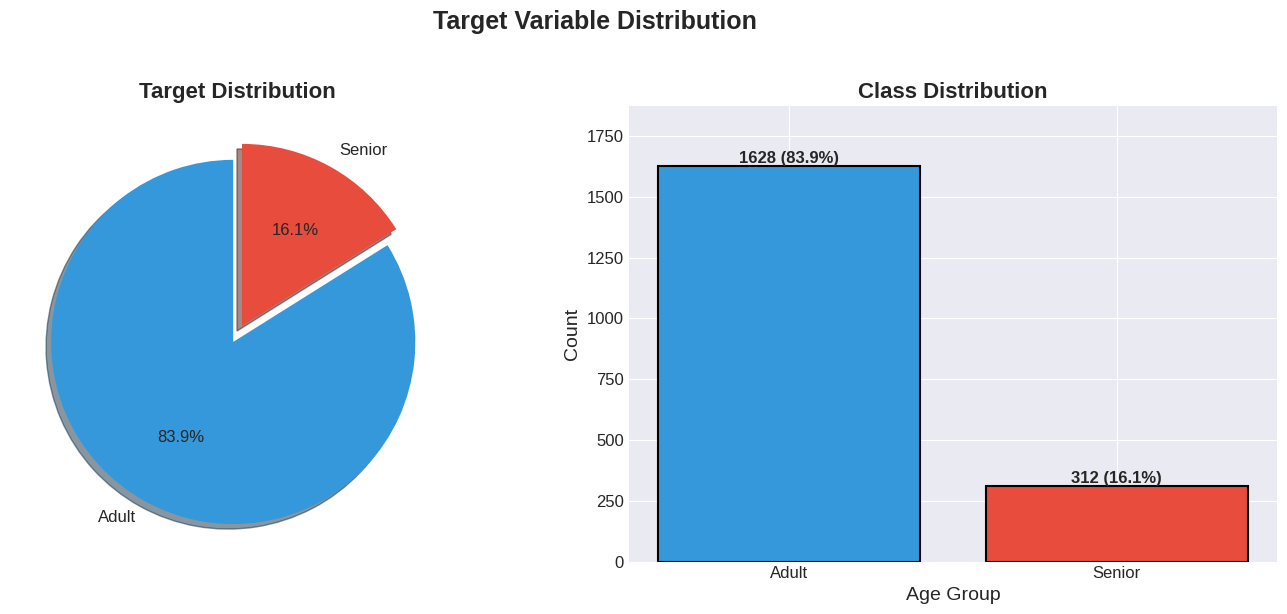

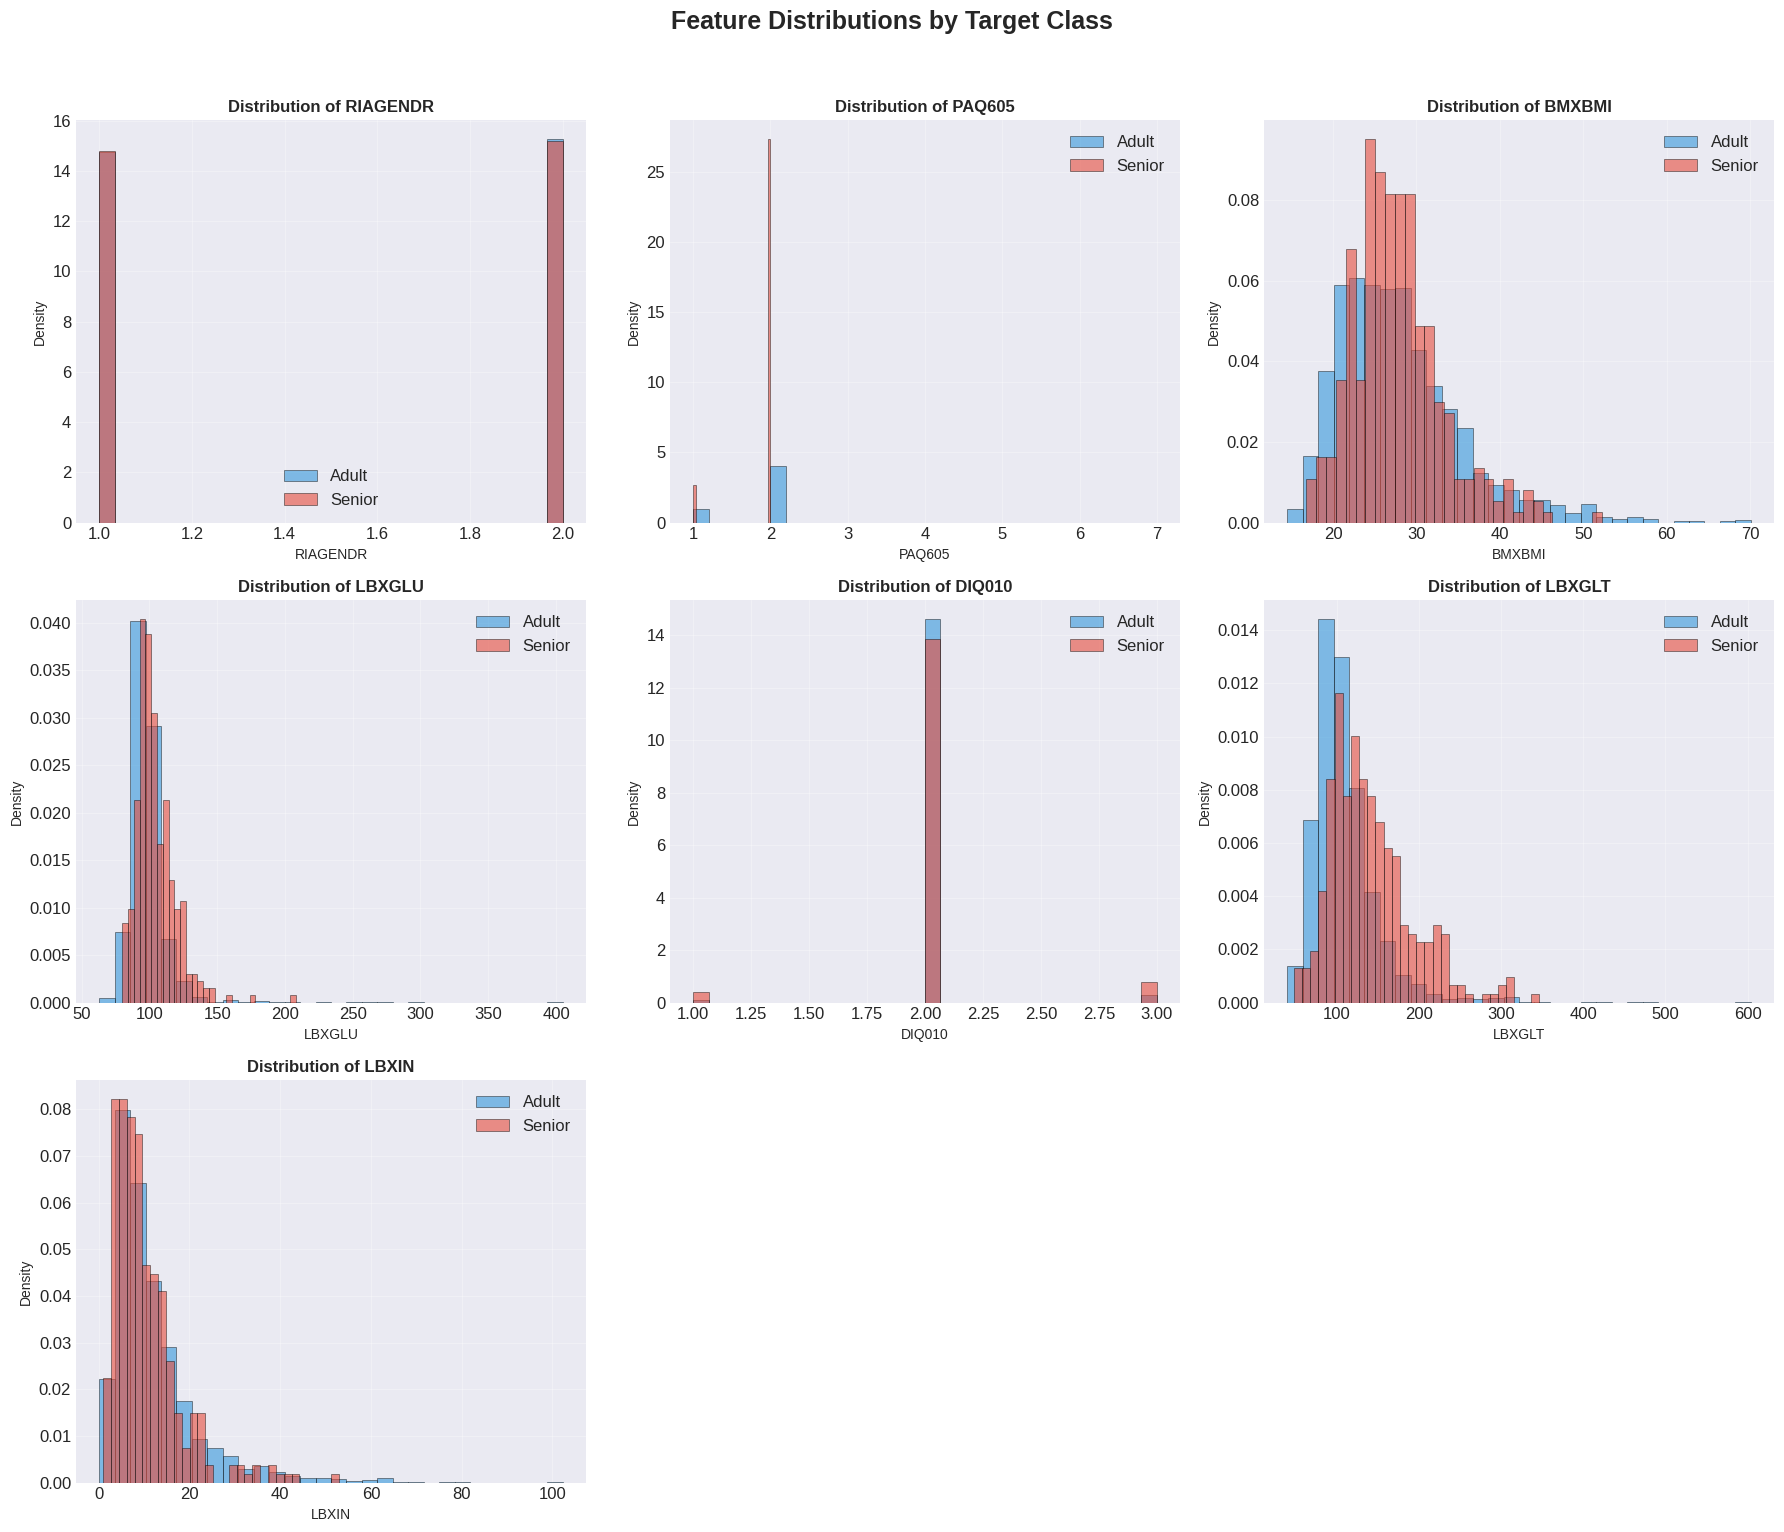

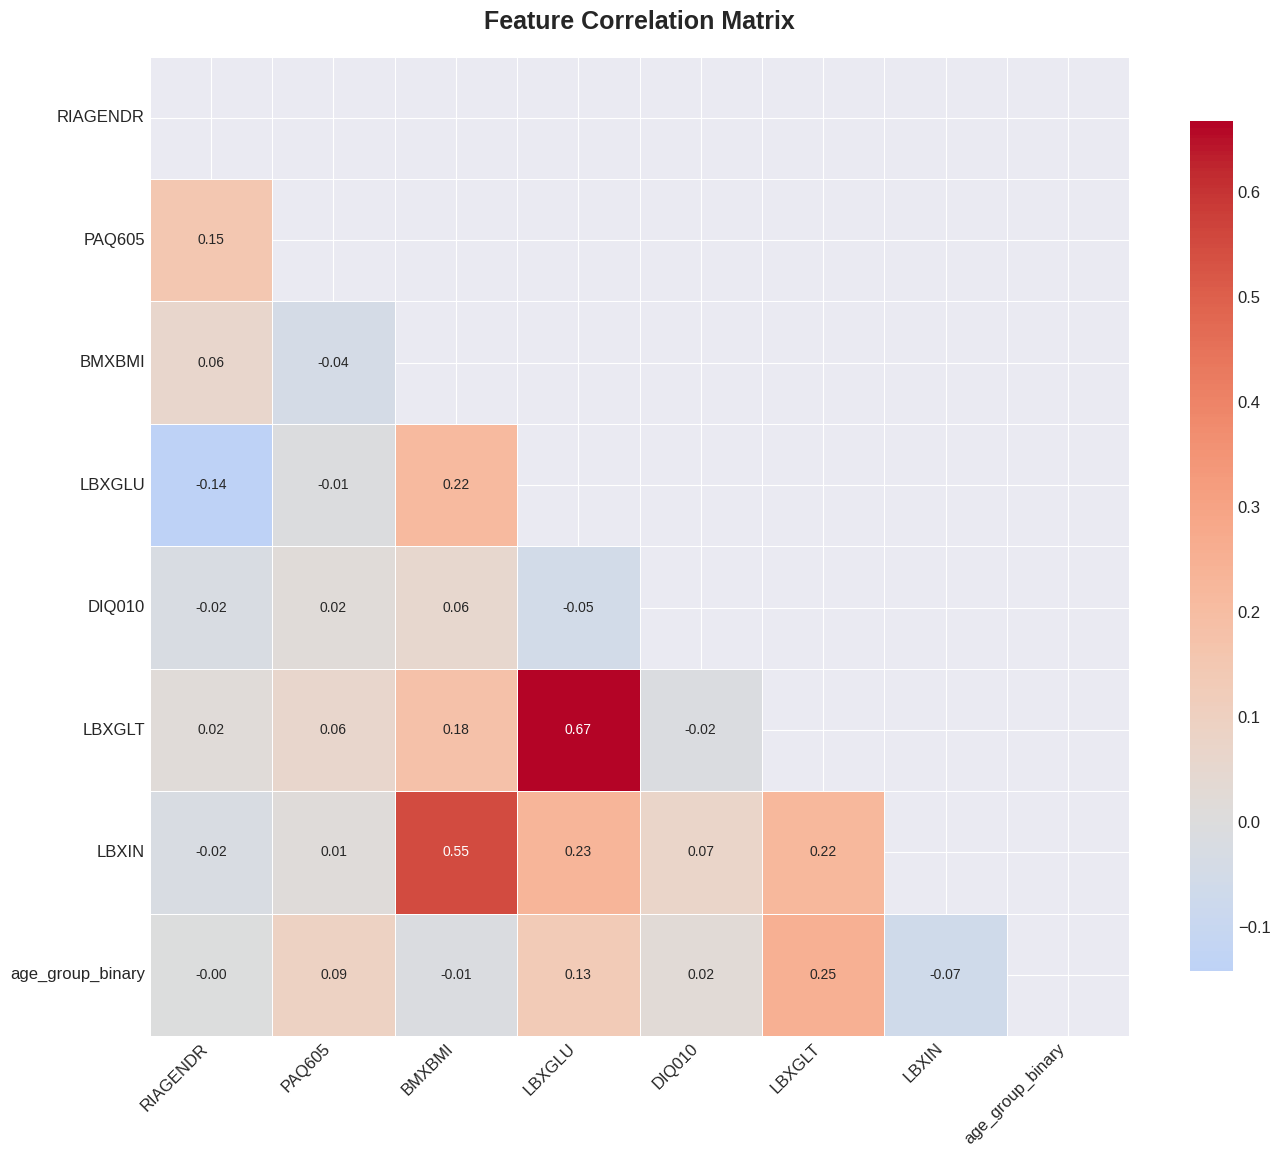

<Figure size 1400x1000 with 0 Axes>

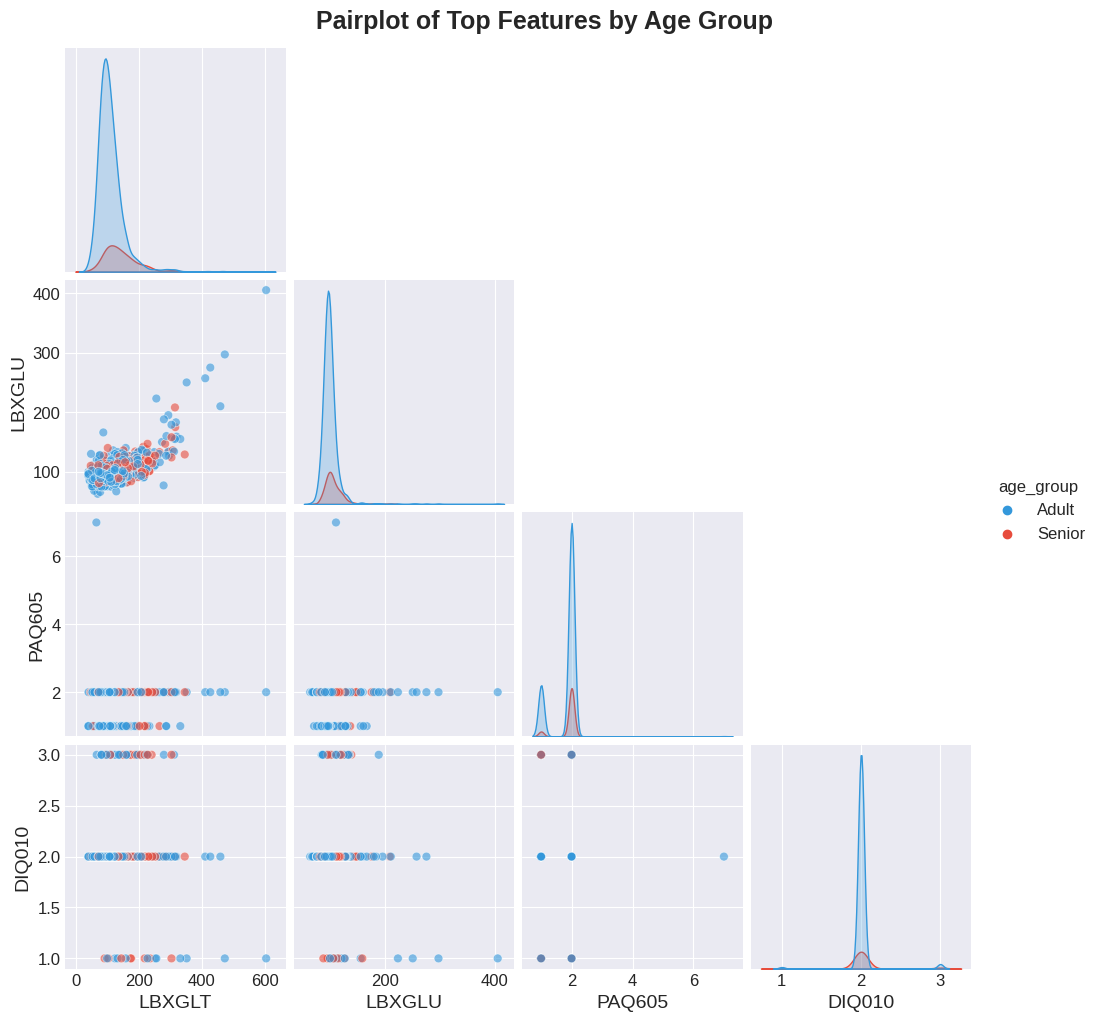

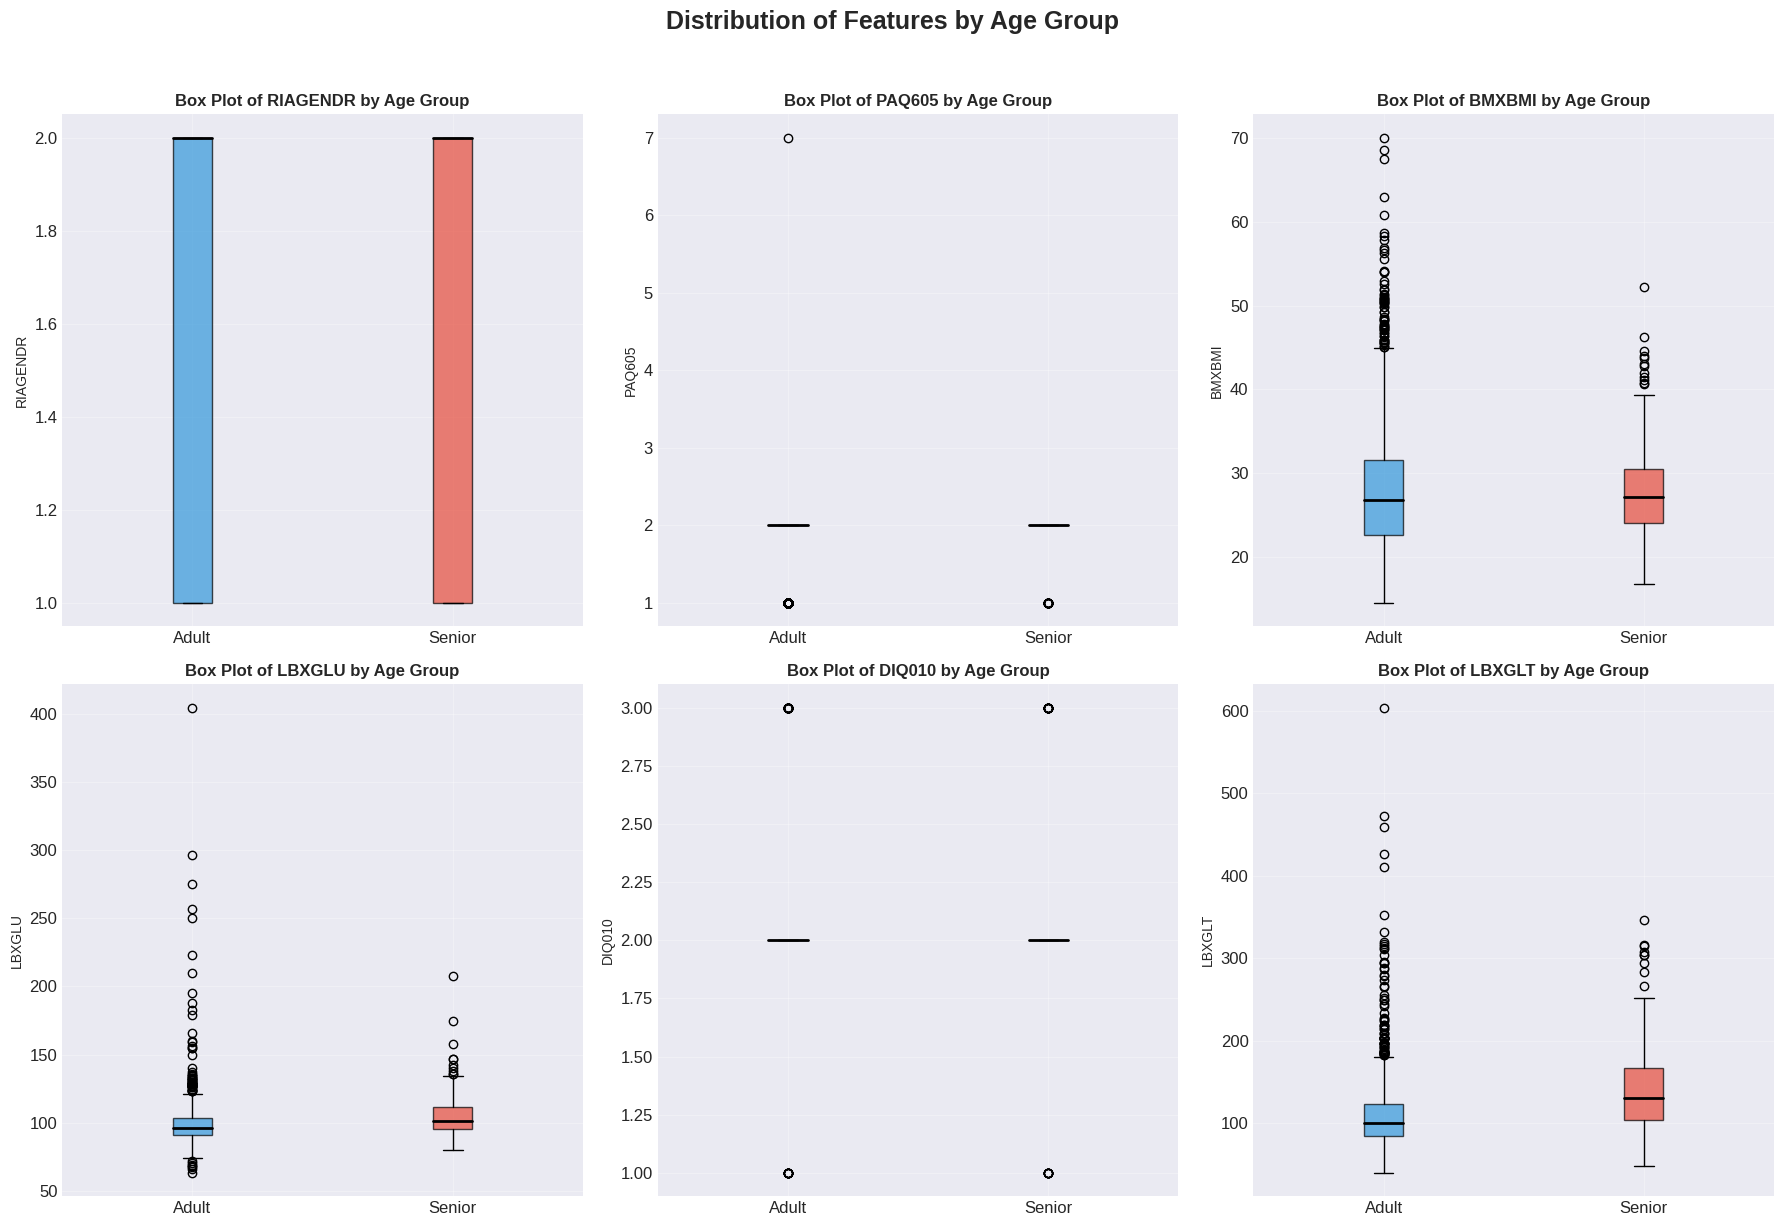

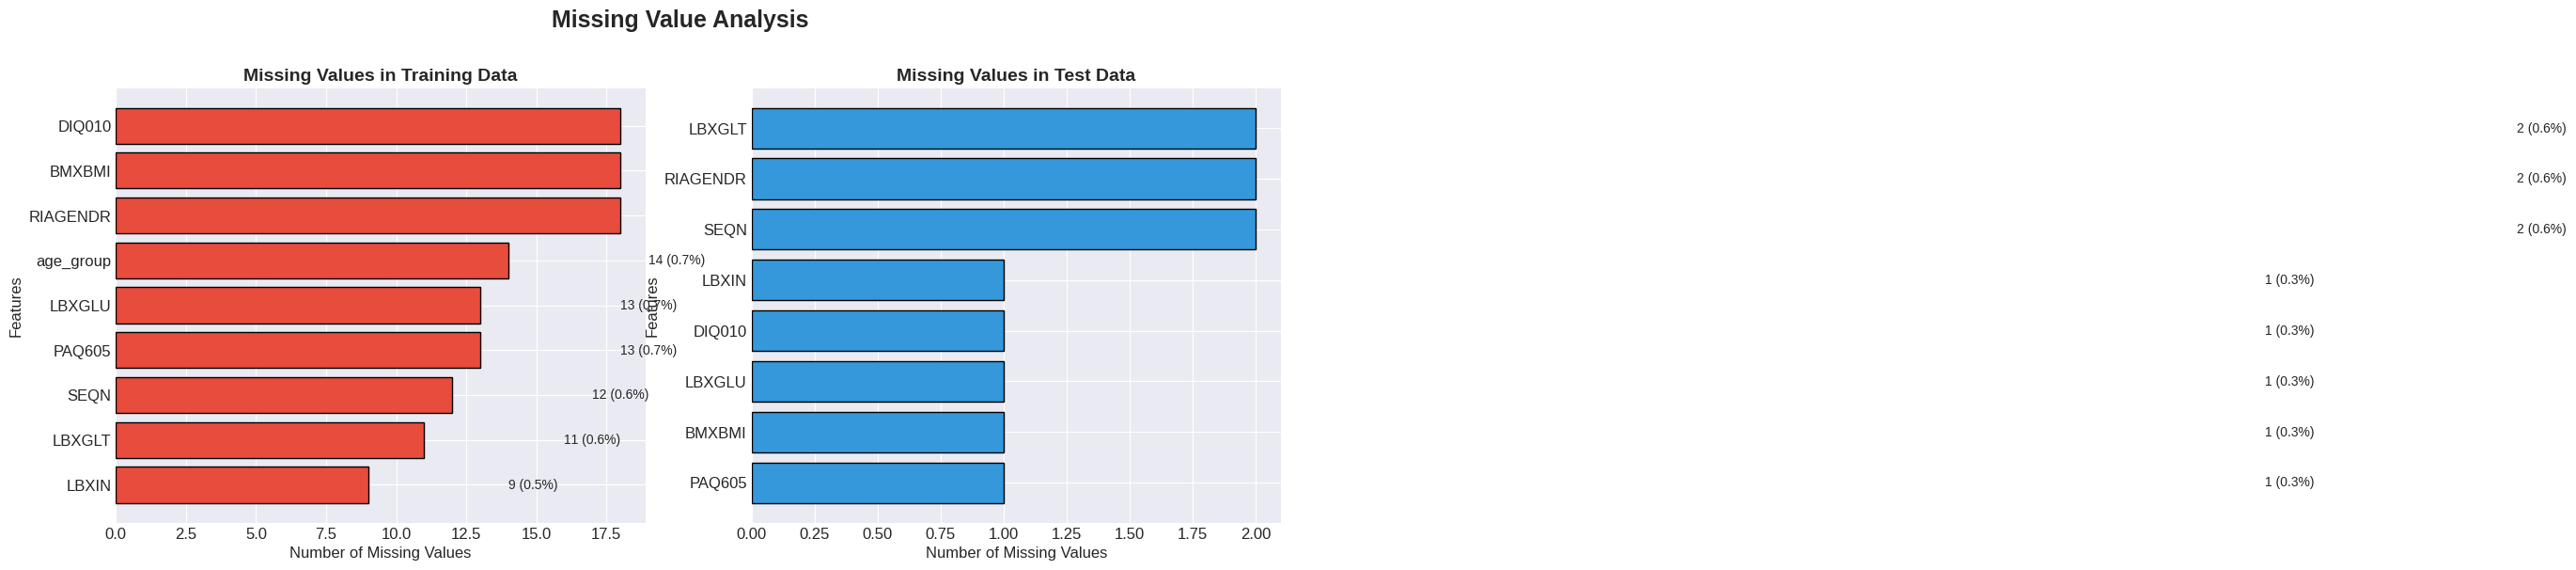

Models not found. Skipping feature importance visualization.


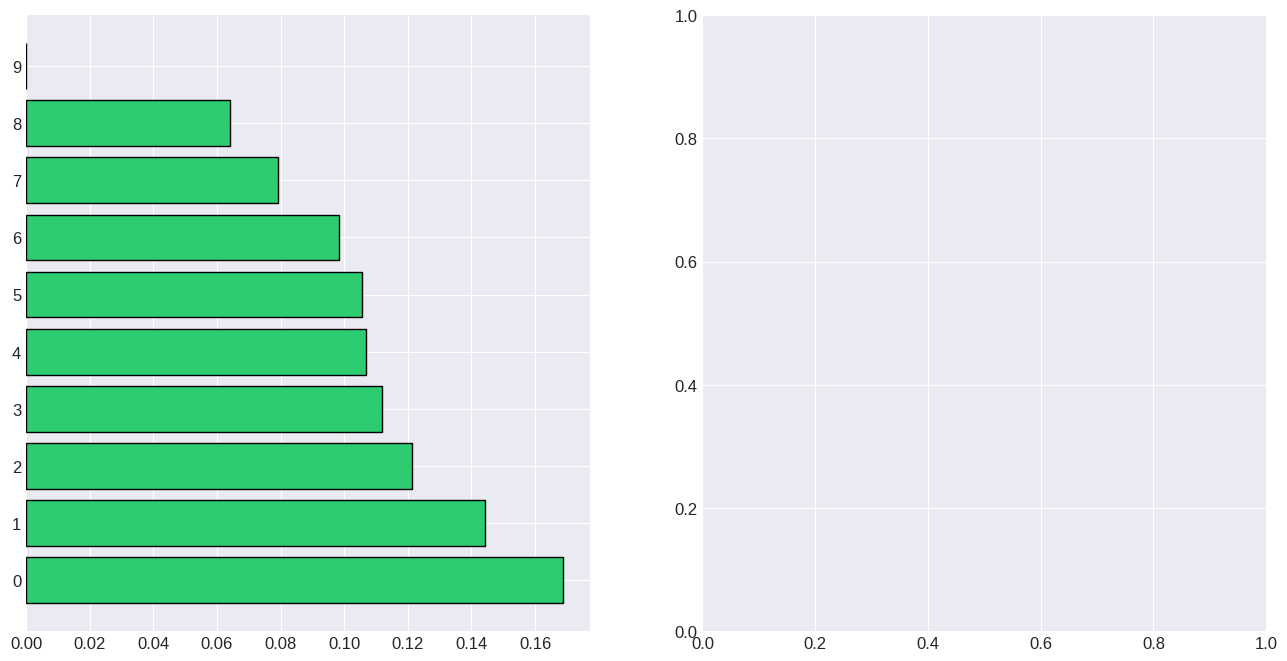

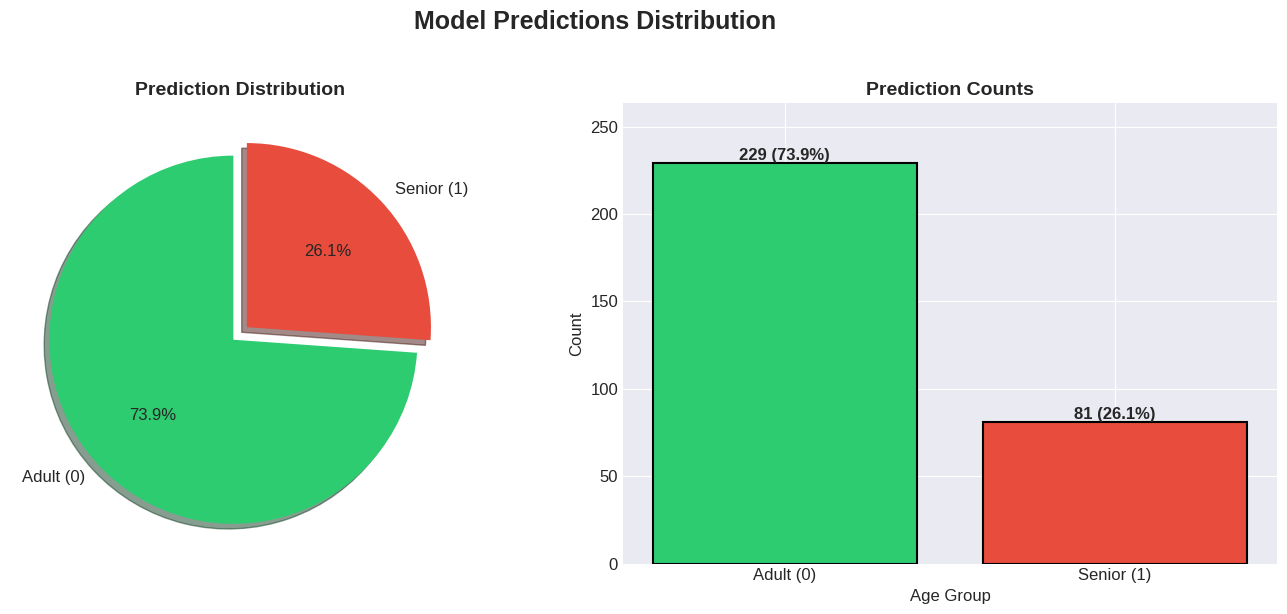

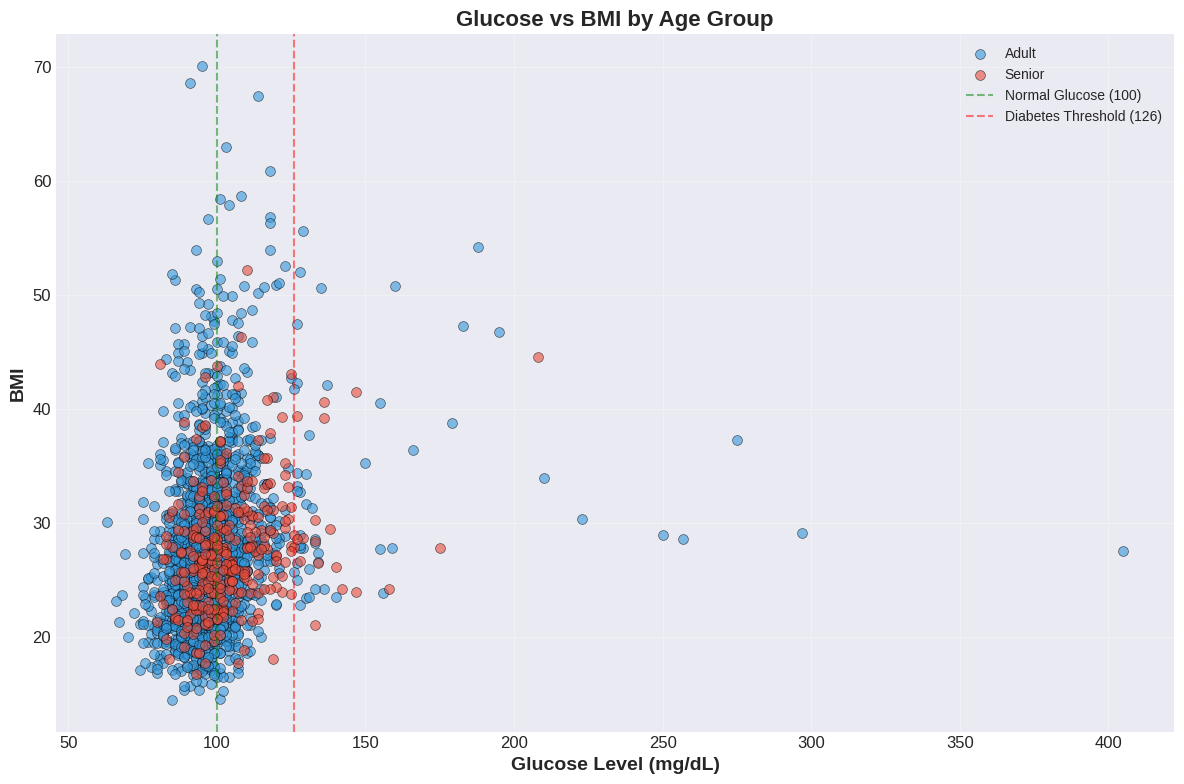

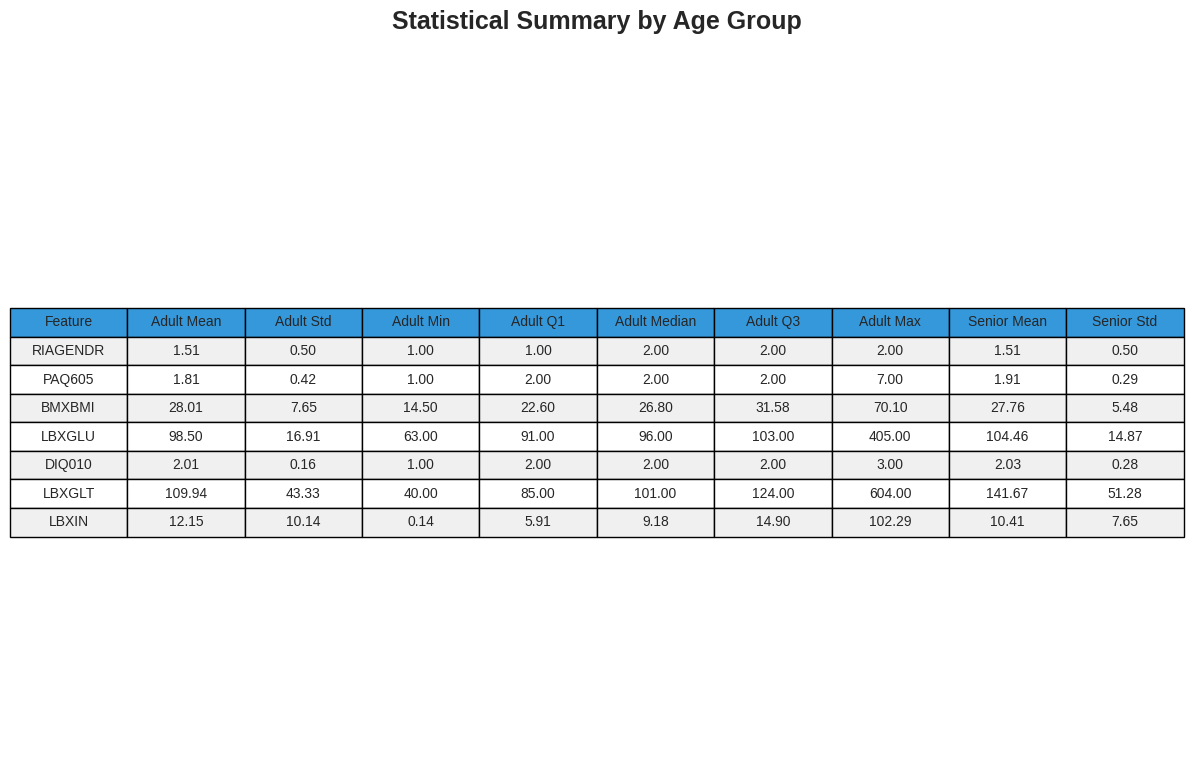


VISUALIZATION COMPLETE!


In [29]:
# ============================================================================
# VISUALIZATION CELL - Add this as a separate cell in your notebook
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings("ignore")

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 12

print("Loading data for visualization...")

# Load the training data
train_df = pd.read_csv("/kaggle/input/nutrition-health-survey/Train_Data.csv")
test_df = pd.read_csv("/kaggle/input/nutrition-health-survey/Test_Data.csv")

# Clean data
train_clean = train_df[train_df['SEQN'].notna()].copy()
train_clean['age_group_binary'] = train_clean['age_group'].map({'Adult': 0, 'Senior': 1})
train_clean = train_clean[train_clean['age_group_binary'].notna()]

# ============================================================================
# 1. TARGET DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
colors = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)
target_counts = train_clean['age_group'].value_counts()
axes[0].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, explode=explode, shadow=True)
axes[0].set_title('Target Distribution', fontsize=16, fontweight='bold')

# Bar chart
ax = axes[1]
bars = ax.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title('Class Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_ylim(0, max(target_counts.values) * 1.15)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)} ({height/len(train_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 2. FEATURE DISTRIBUTIONS BY TARGET
# ============================================================================

numeric_cols = ['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        ax = axes[idx]
        # Plot distribution for each class
        for target, color, label in zip([0, 1], ['#3498db', '#e74c3c'], ['Adult', 'Senior']):
            data = train_clean[train_clean['age_group_binary'] == target][col].dropna()
            ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True, edgecolor='black', linewidth=0.5)
        ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)

# Remove empty subplot
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Feature Distributions by Target Class', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 3. CORRELATION HEATMAP
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 12))

# Calculate correlation matrix
corr_matrix = train_clean[numeric_cols + ['age_group_binary']].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})

plt.title('Feature Correlation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================================================
# 4. PAIRPLOT OF TOP FEATURES
# ============================================================================

# Select top features based on correlation with target
corr_with_target = corr_matrix['age_group_binary'].sort_values(ascending=False)
top_features = corr_with_target.index[1:5].tolist()  # Top 4 features

if len(top_features) >= 2:
    fig = plt.figure(figsize=(14, 10))
    
    # Pairplot with hue
    g = sns.pairplot(train_clean[top_features + ['age_group']], 
                     hue='age_group', palette=['#3498db', '#e74c3c'],
                     diag_kind='kde', corner=True, plot_kws={'alpha': 0.6, 's': 40})
    
    g.fig.suptitle('Pairplot of Top Features by Age Group', 
                   fontsize=18, fontweight='bold', y=1.02)
    plt.show()
else:
    print("Not enough features for pairplot visualization")

# ============================================================================
# 5. BOX PLOTS FOR NUMERICAL FEATURES
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:-1]):  # Skip last column if odd
    if idx < len(axes):
        ax = axes[idx]
        # Box plot by target
        data_to_plot = [train_clean[train_clean['age_group_binary'] == 0][col].dropna(),
                       train_clean[train_clean['age_group_binary'] == 1][col].dropna()]
        
        bp = ax.boxplot(data_to_plot, labels=['Adult', 'Senior'], patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
        
        # Color the boxes
        for patch, color in zip(bp['boxes'], ['#3498db', '#e74c3c']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_title(f'Box Plot of {col} by Age Group', fontsize=12, fontweight='bold')
        ax.set_ylabel(col, fontsize=10)
        ax.grid(True, alpha=0.3)

# Remove empty subplot
for idx in range(len(numeric_cols)-1, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Features by Age Group', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 6. MISSING VALUES ANALYSIS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training data missing values
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=True)

if len(missing_train) > 0:
    ax1 = axes[0]
    bars = ax1.barh(missing_train.index, missing_train.values, color='#e74c3c', edgecolor='black', linewidth=1)
    ax1.set_title('Missing Values in Training Data', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Missing Values', fontsize=12)
    ax1.set_ylabel('Features', fontsize=12)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax1.text(width + 5, bar.get_y() + bar.get_height()/2,
                f'{int(width)} ({width/len(train_df)*100:.1f}%)',
                ha='left', va='center', fontsize=10)

# Test data missing values
missing_test = test_df.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=True)

if len(missing_test) > 0:
    ax2 = axes[1]
    bars = ax2.barh(missing_test.index, missing_test.values, color='#3498db', edgecolor='black', linewidth=1)
    ax2.set_title('Missing Values in Test Data', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Missing Values', fontsize=12)
    ax2.set_ylabel('Features', fontsize=12)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 5, bar.get_y() + bar.get_height()/2,
                f'{int(width)} ({width/len(test_df)*100:.1f}%)',
                ha='left', va='center', fontsize=10)

plt.suptitle('Missing Value Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 7. FEATURE IMPORTANCE (if models are saved)
# ============================================================================

import joblib

try:
    # Load models if available
    xgb_model = joblib.load("/kaggle/working/xgb_model.joblib")
    lgb_model = joblib.load("/kaggle/working/lgb_model.joblib")
    
    # Get feature names (use the cleaned data columns without engineered features)
    feature_names = numeric_cols
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # XGBoost feature importance
    if hasattr(xgb_model, 'feature_importances_'):
        ax = axes[0]
        importances = xgb_model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]  # Top 10
        
        bars = ax.barh(range(len(indices)), importances[indices], color='#2ecc71', edgecolor='black', linewidth=1)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices])
        ax.set_xlabel('Feature Importance', fontsize=12)
        ax.set_title('XGBoost - Top 10 Feature Importances', fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3)
        
        # Add value labels
        for i, (bar, idx) in enumerate(zip(bars, indices)):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{importances[idx]:.3f}', ha='left', va='center', fontsize=10)
    
    # LightGBM feature importance
    if hasattr(lgb_model, 'feature_importances_'):
        ax = axes[1]
        importances = lgb_model.feature_importances_
        indices = np.argsort(importances)[::-1][:10]  # Top 10
        
        bars = ax.barh(range(len(indices)), importances[indices], color='#e67e22', edgecolor='black', linewidth=1)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices])
        ax.set_xlabel('Feature Importance', fontsize=12)
        ax.set_title('LightGBM - Top 10 Feature Importances', fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3)
        
        # Add value labels
        for i, (bar, idx) in enumerate(zip(bars, indices)):
            ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                   f'{importances[idx]:.0f}', ha='left', va='center', fontsize=10)
    
    plt.suptitle('Model Feature Importance Comparison', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
except:
    print("Models not found. Skipping feature importance visualization.")

# ============================================================================
# 8. PREDICTION DISTRIBUTION (if submission exists)
# ============================================================================

try:
    submission = pd.read_csv("/kaggle/working/final_submission.csv")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Pie chart of predictions
    pred_counts = submission['age_group'].value_counts()
    colors_pred = ['#2ecc71', '#e74c3c']
    explode_pred = (0.05, 0.05)
    
    ax1 = axes[0]
    ax1.pie(pred_counts.values, labels=['Adult (0)', 'Senior (1)'], 
            autopct='%1.1f%%', startangle=90, colors=colors_pred, explode=explode_pred, shadow=True)
    ax1.set_title('Prediction Distribution', fontsize=14, fontweight='bold')
    
    # Bar chart of predictions
    ax2 = axes[1]
    bars = ax2.bar(pred_counts.index, pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
    ax2.set_title('Prediction Counts', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Age Group', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels(['Adult (0)', 'Senior (1)'])
    ax2.set_ylim(0, max(pred_counts.values) * 1.15)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)} ({height/len(submission)*100:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.suptitle('Model Predictions Distribution', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
except:
    print("Submission file not found. Skipping prediction visualization.")

# ============================================================================
# 9. AGE VS GLUCOSE LEVELS
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot with age groups
for target, color, label, marker in zip([0, 1], ['#3498db', '#e74c3c'], 
                                        ['Adult', 'Senior'], ['o', 's']):
    data = train_clean[train_clean['age_group_binary'] == target]
    ax.scatter(data['LBXGLU'], data['BMXBMI'], 
              c=color, label=label, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Glucose Level (mg/dL)', fontsize=14, fontweight='bold')
ax.set_ylabel('BMI', fontsize=14, fontweight='bold')
ax.set_title('Glucose vs BMI by Age Group', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

# Add vertical line for normal glucose
ax.axvline(x=100, color='green', linestyle='--', alpha=0.5, label='Normal Glucose (100)')
ax.axvline(x=126, color='red', linestyle='--', alpha=0.5, label='Diabetes Threshold (126)')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================================
# 10. SUMMARY STATISTICS TABLE
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')

# Create summary table
summary_data = []
for col in numeric_cols:
    adult_stats = train_clean[train_clean['age_group_binary'] == 0][col].describe()
    senior_stats = train_clean[train_clean['age_group_binary'] == 1][col].describe()
    
    summary_data.append([
        col,
        f"{adult_stats['mean']:.2f}",
        f"{adult_stats['std']:.2f}",
        f"{adult_stats['min']:.2f}",
        f"{adult_stats['25%']:.2f}",
        f"{adult_stats['50%']:.2f}",
        f"{adult_stats['75%']:.2f}",
        f"{adult_stats['max']:.2f}",
        f"{senior_stats['mean']:.2f}",
        f"{senior_stats['std']:.2f}"
    ])

columns = ['Feature', 'Adult Mean', 'Adult Std', 'Adult Min', 'Adult Q1', 
           'Adult Median', 'Adult Q3', 'Adult Max', 'Senior Mean', 'Senior Std']

table = ax.table(cellText=summary_data, colLabels=columns,
                cellLoc='center', loc='center',
                colColours=['#3498db']*len(columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color rows
for i, row in enumerate(summary_data):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[(i+1, j)].set_facecolor('#f0f0f0')
        else:
            table[(i+1, j)].set_facecolor('#ffffff')

plt.title('Statistical Summary by Age Group', fontsize=18, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("VISUALIZATION COMPLETE!")
print("="*60)